In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import fft, signal
from scipy.io import loadmat
from scipy.signal import hilbert, spectrogram, butter, filtfilt
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings, os, gc
warnings.filterwarnings('ignore')
 
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 9

In [2]:
# ============================================================
# 0. Setup & Load
# ============================================================
fs = 12000
RPM = 1772
fr = RPM/60
n_balls=9
Bd=7.938
Pd=39.04
alpha=0
BPFO = (n_balls/2)*fr*(1-(Bd/Pd))
BPFI = (n_balls/2)*fr*(1+(Bd/Pd))
BSF  = (Pd/(2*Bd))*fr*(1-(Bd/Pd)**2)
FTF  = (fr/2)*(1-(Bd/Pd))
 
print("="*55)
print("  CWRU Fault Frequencies (SKF 6205, 1772 RPM / 1HP)")
print("="*55)
print(f"  fr={fr:.2f}, BPFO={BPFO:.2f}, BPFI={BPFI:.2f}, BSF={BSF:.2f}, FTF={FTF:.2f} Hz")
 
DATA_DIR = './raw'
SAVE_DIR = './results'
# Use only first 60000 samples (5 seconds) to save memory
MAX_SAMPLES = 60000

  CWRU Fault Frequencies (SKF 6205, 1772 RPM / 1HP)
  fr=29.53, BPFO=105.88, BPFI=159.92, BSF=69.62, FTF=11.76 Hz


In [3]:
def load_cwru(filepath, max_n=MAX_SAMPLES):
    mat = loadmat(filepath)
    de_keys = [k for k in mat.keys() if 'DE_time' in k and not k.startswith('__')]
    if len(de_keys) > 1:
        code = os.path.basename(filepath).split('_')[-1].replace('.mat','')
        matched = [k for k in de_keys if code in k]
        if matched: de_keys = matched
    data = mat[de_keys[0]].flatten()[:max_n]
    rpm_keys = [k for k in mat.keys() if 'RPM' in k]
    rpm = mat[rpm_keys[0]].flatten()[0] if rpm_keys else RPM
    del mat
    gc.collect()
    return data, rpm
 
files = {
    'Normal':'Time_Normal_1_098.mat', 'IR007':'IR007_1_110.mat',
    'IR014':'IR014_1_175.mat', 'IR021':'IR021_1_214.mat',
    'OR007':'OR007_6_1_136.mat', 'OR014':'OR014_6_1_202.mat',
    'OR021':'OR021_6_1_239.mat', 'Ball007':'B007_1_123.mat',
    'Ball014':'B014_1_190.mat', 'Ball021':'B021_1_227.mat',
}

In [4]:
data_dict = {}
print("\n--- Loading (first 5s each) ---")
for label, fname in files.items():
    sig, rpm = load_cwru(os.path.join(DATA_DIR, fname))
    data_dict[label] = sig
    print(f"  {label:10s}: {len(sig)} samples, RPM={rpm}")
 
fault_ff = {'Normal':None,'OR007':BPFO,'OR014':BPFO,'OR021':BPFO,
            'IR007':BPFI,'IR014':BPFI,'IR021':BPFI,
            'Ball007':2*BSF,'Ball014':2*BSF,'Ball021':2*BSF}
 
rep = ['Normal','OR007','IR007','Ball007']
colors4 = ['#2196F3','#FF5722','#4CAF50','#9C27B0']


--- Loading (first 5s each) ---
  Normal    : 60000 samples, RPM=1772
  IR007     : 60000 samples, RPM=1772
  IR014     : 60000 samples, RPM=1772
  IR021     : 60000 samples, RPM=1774
  OR007     : 60000 samples, RPM=1774
  OR014     : 60000 samples, RPM=1772
  OR021     : 60000 samples, RPM=1771
  Ball007   : 60000 samples, RPM=1772
  Ball014   : 60000 samples, RPM=1772
  Ball021   : 60000 samples, RPM=1774


In [5]:
# ============================================================
# STEP 1: FFT
# ============================================================
print("\n>>> STEP 1: FFT")


>>> STEP 1: FFT


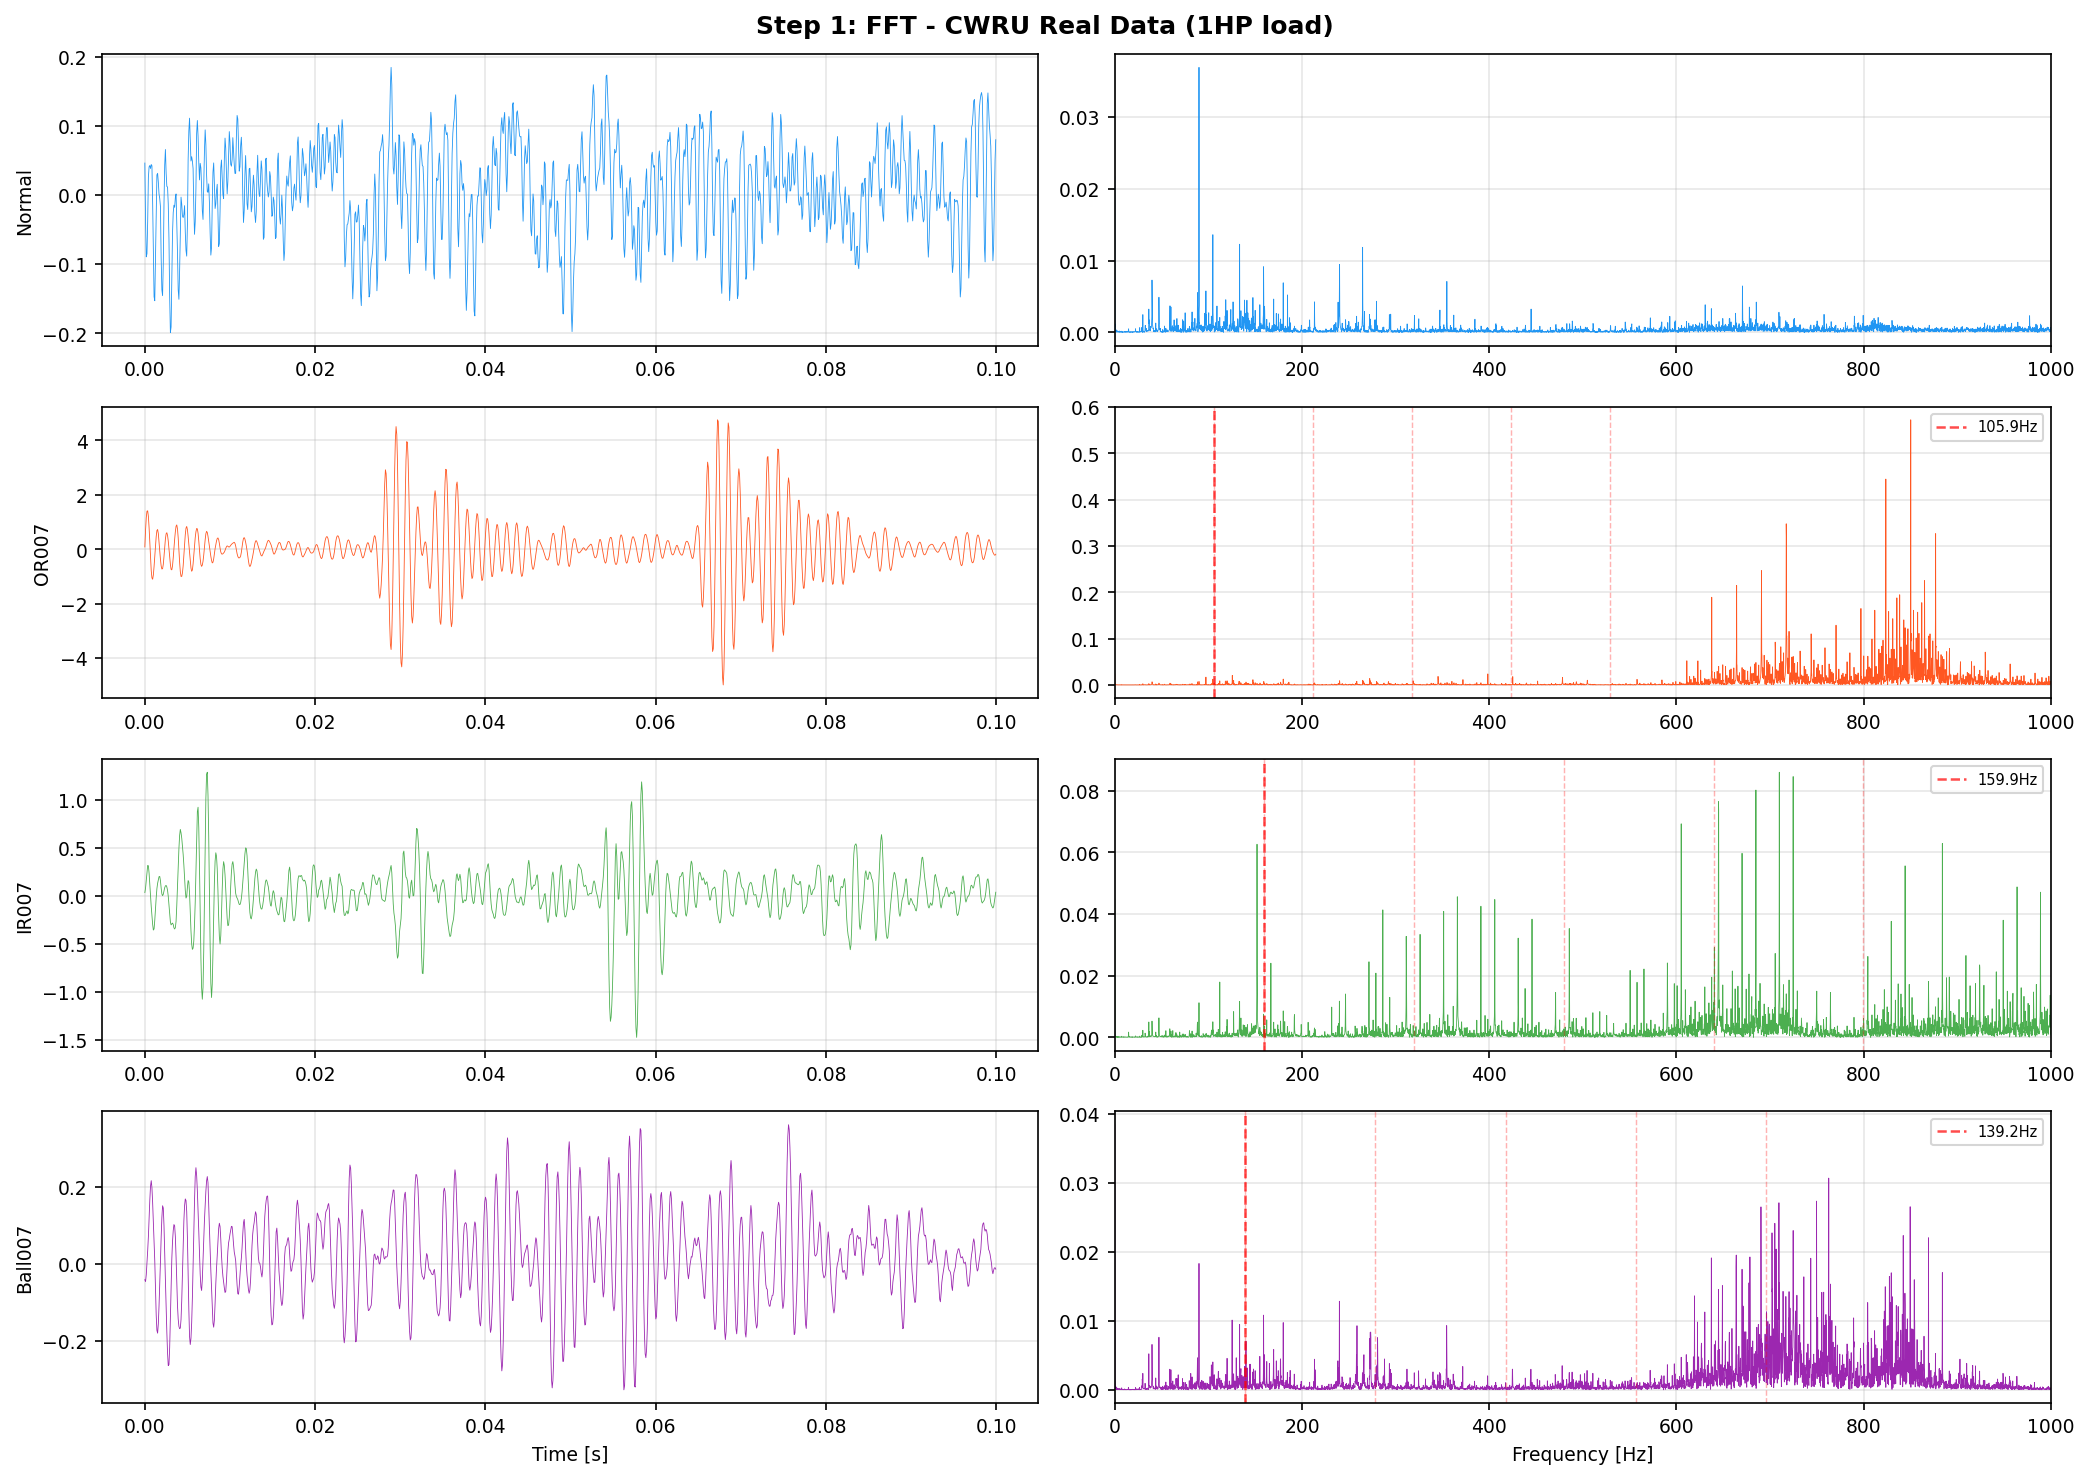

  saved step1_fft.png


In [6]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for i, label in enumerate(rep):
    x = data_dict[label]
    N = len(x)
    freq = fft.rfftfreq(N, 1/fs)
    X_mag = np.abs(fft.rfft(x))/(N/2)
    t = np.arange(N)/fs
    
    n_show = int(0.1*fs)
    axes[i,0].plot(t[:n_show], x[:n_show], lw=0.4, color=colors4[i])
    axes[i,0].set_ylabel(label, fontsize=9)
    axes[i,0].grid(True, alpha=0.3)
    
    axes[i,1].plot(freq, X_mag, lw=0.4, color=colors4[i])
    axes[i,1].set_xlim(0, 1000)
    axes[i,1].grid(True, alpha=0.3)
    ff = fault_ff[label]
    if ff:
        for h in range(1,6): axes[i,1].axvline(ff*h, color='red', alpha=0.3, ls='--', lw=0.7)
        axes[i,1].axvline(ff, color='red', alpha=0.7, ls='--', lw=1.2, label=f'{ff:.1f}Hz')
        axes[i,1].legend(fontsize=7)
axes[-1,0].set_xlabel('Time [s]')
axes[-1,1].set_xlabel('Frequency [Hz]')
fig.suptitle('Step 1: FFT - CWRU Real Data (1HP load)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'step1_fft.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step1_fft.png")

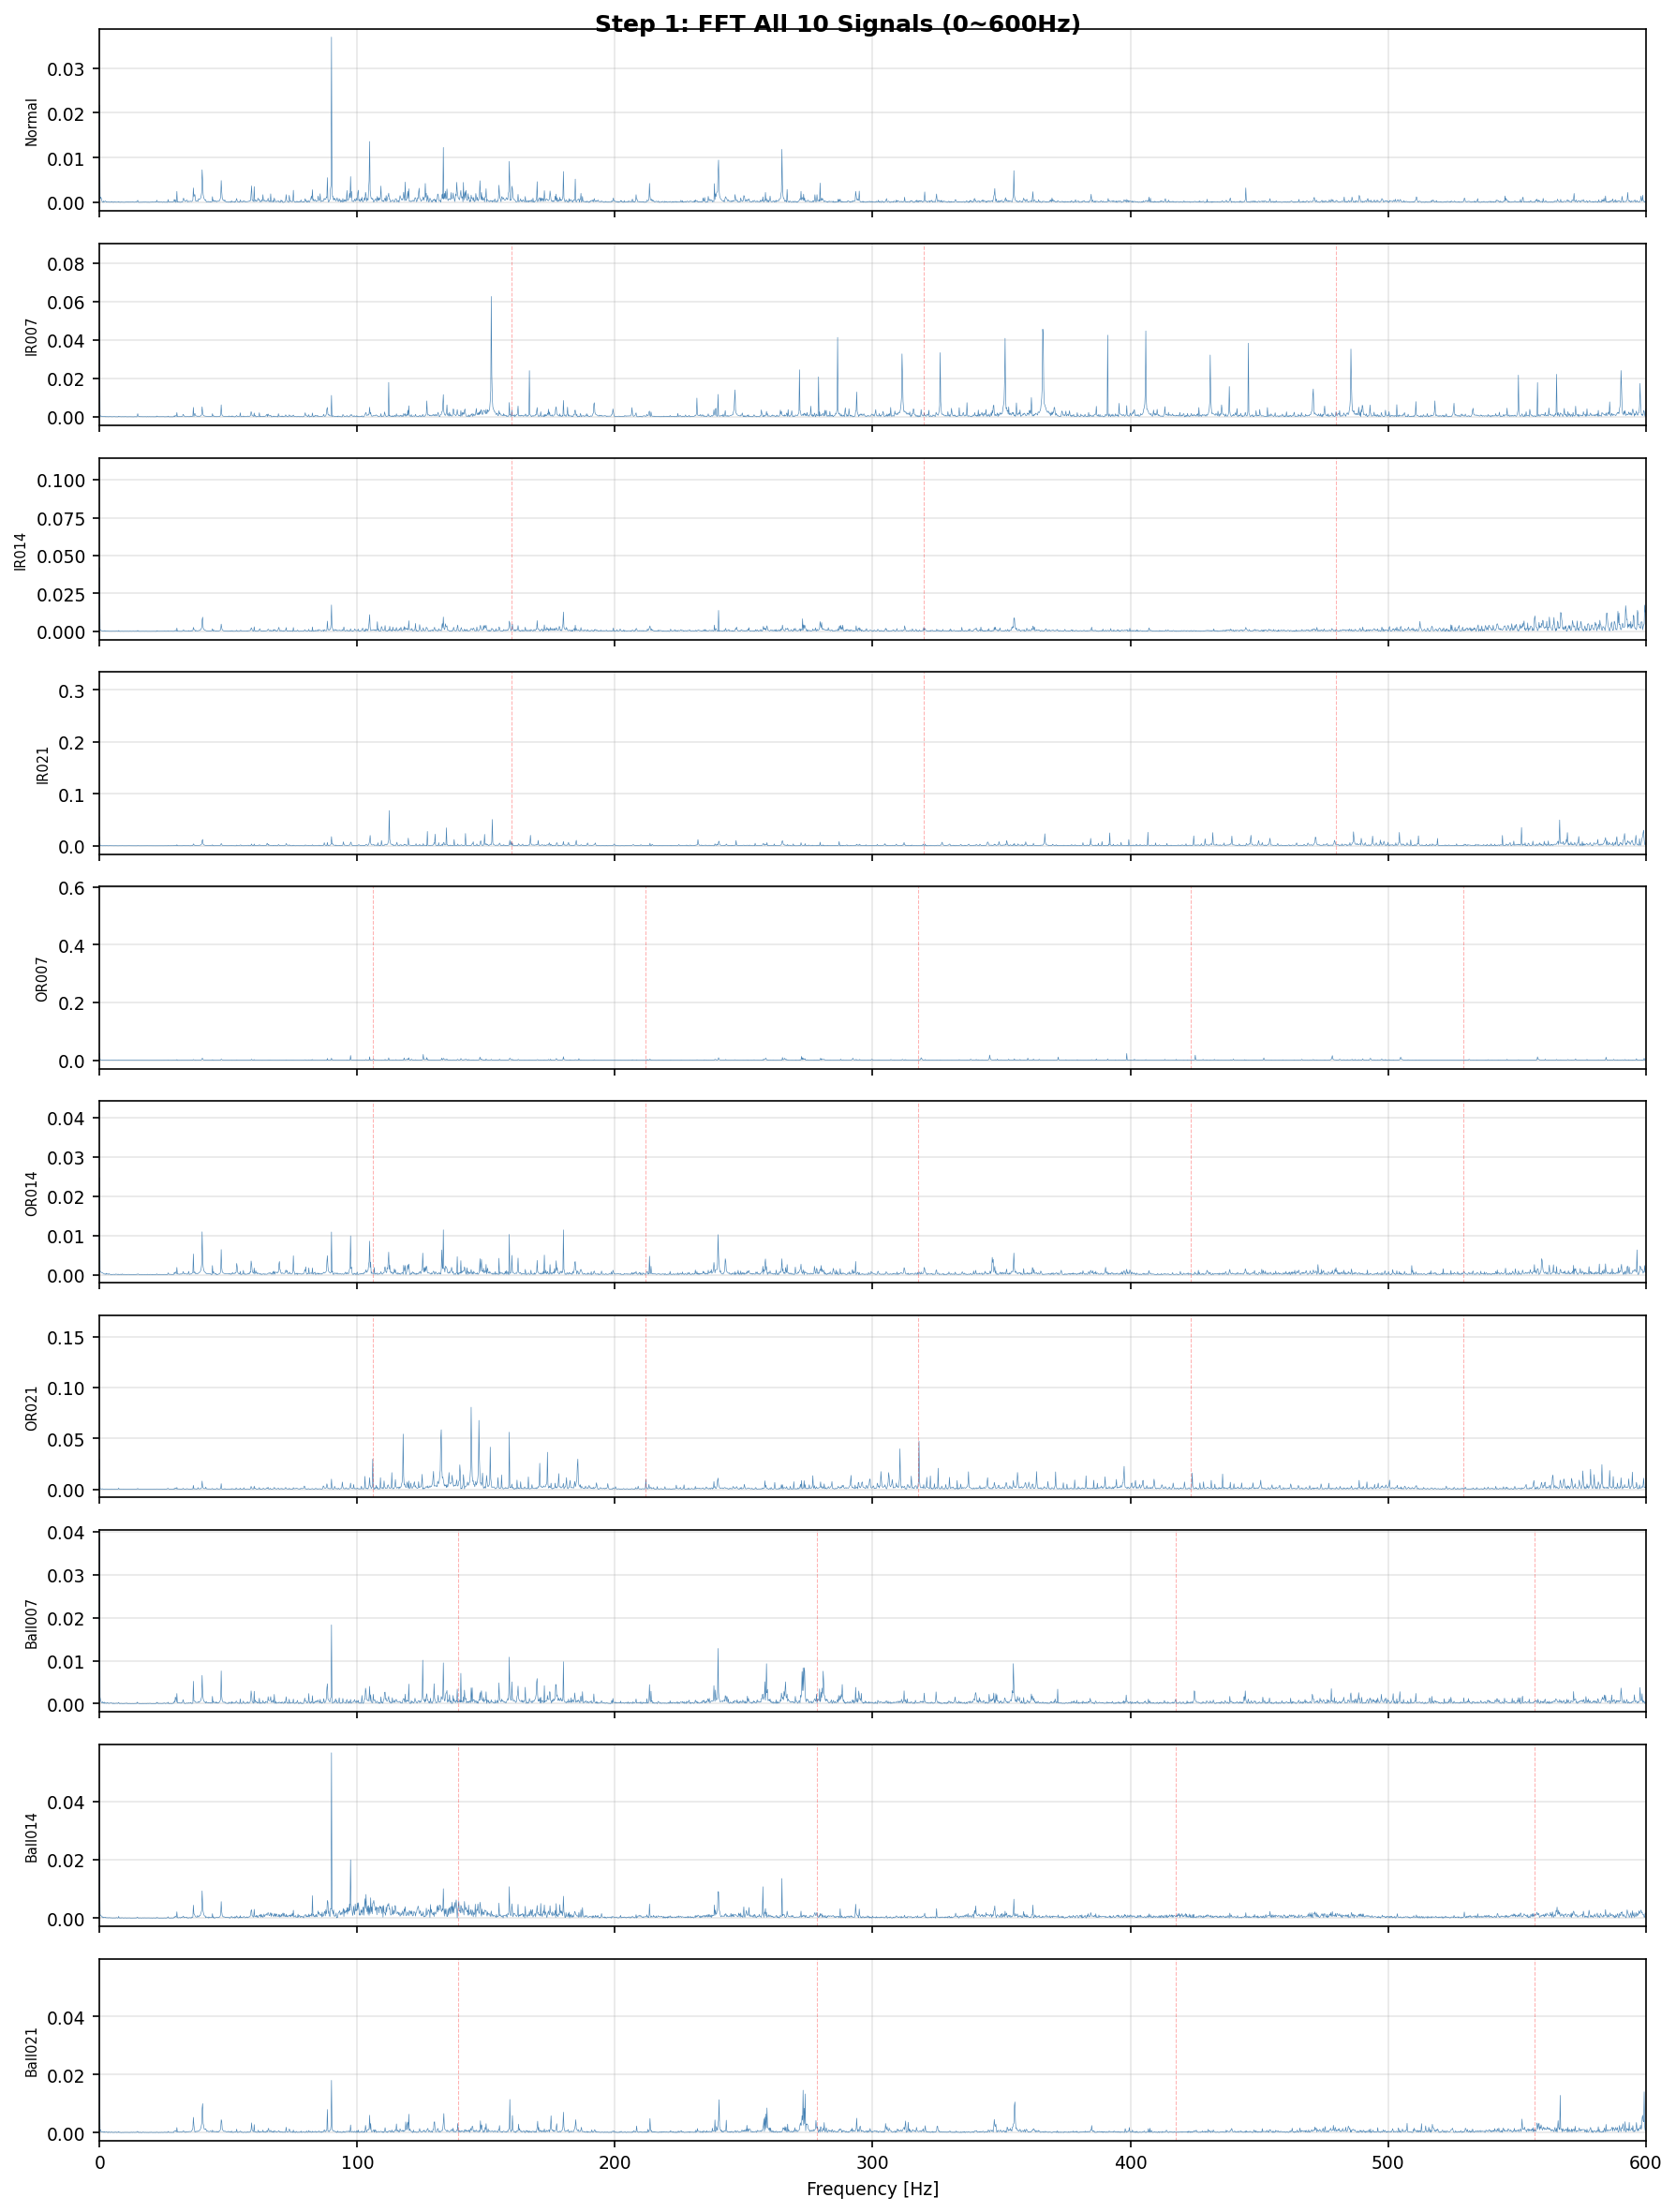

  saved step1_fft_all.png


23618

In [7]:
# All 10 signals FFT
fig, axes = plt.subplots(10, 1, figsize=(12, 16), sharex=True)
for i, label in enumerate(data_dict.keys()):
    x = data_dict[label]
    N=len(x)
    freq=fft.rfftfreq(N,1/fs)
    X_mag = np.abs(fft.rfft(x))/(N/2)
    axes[i].plot(freq, X_mag, lw=0.3, color='steelblue')
    axes[i].set_xlim(0, 600)
    axes[i].set_ylabel(label, fontsize=7)
    axes[i].grid(True, alpha=0.3)
    ff = fault_ff.get(label)
    if ff:
        for h in range(1,6): axes[i].axvline(ff*h, color='red', alpha=0.3, ls='--', lw=0.5)
axes[-1].set_xlabel('Frequency [Hz]')
fig.suptitle('Step 1: FFT All 10 Signals (0~600Hz)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'step1_fft_all.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step1_fft_all.png")
gc.collect()

In [8]:
# ============================================================
# STEP 2: FILTERING
# ============================================================
print("\n>>> STEP 2: Filtering")
cutoff_lpf = 500
b_lpf, a_lpf = butter(4, cutoff_lpf, btype='low', fs=fs)
low_bp, high_bp = 2000, 5000
b_bp, a_bp = butter(4, [low_bp,high_bp], btype='band', fs=fs)


>>> STEP 2: Filtering


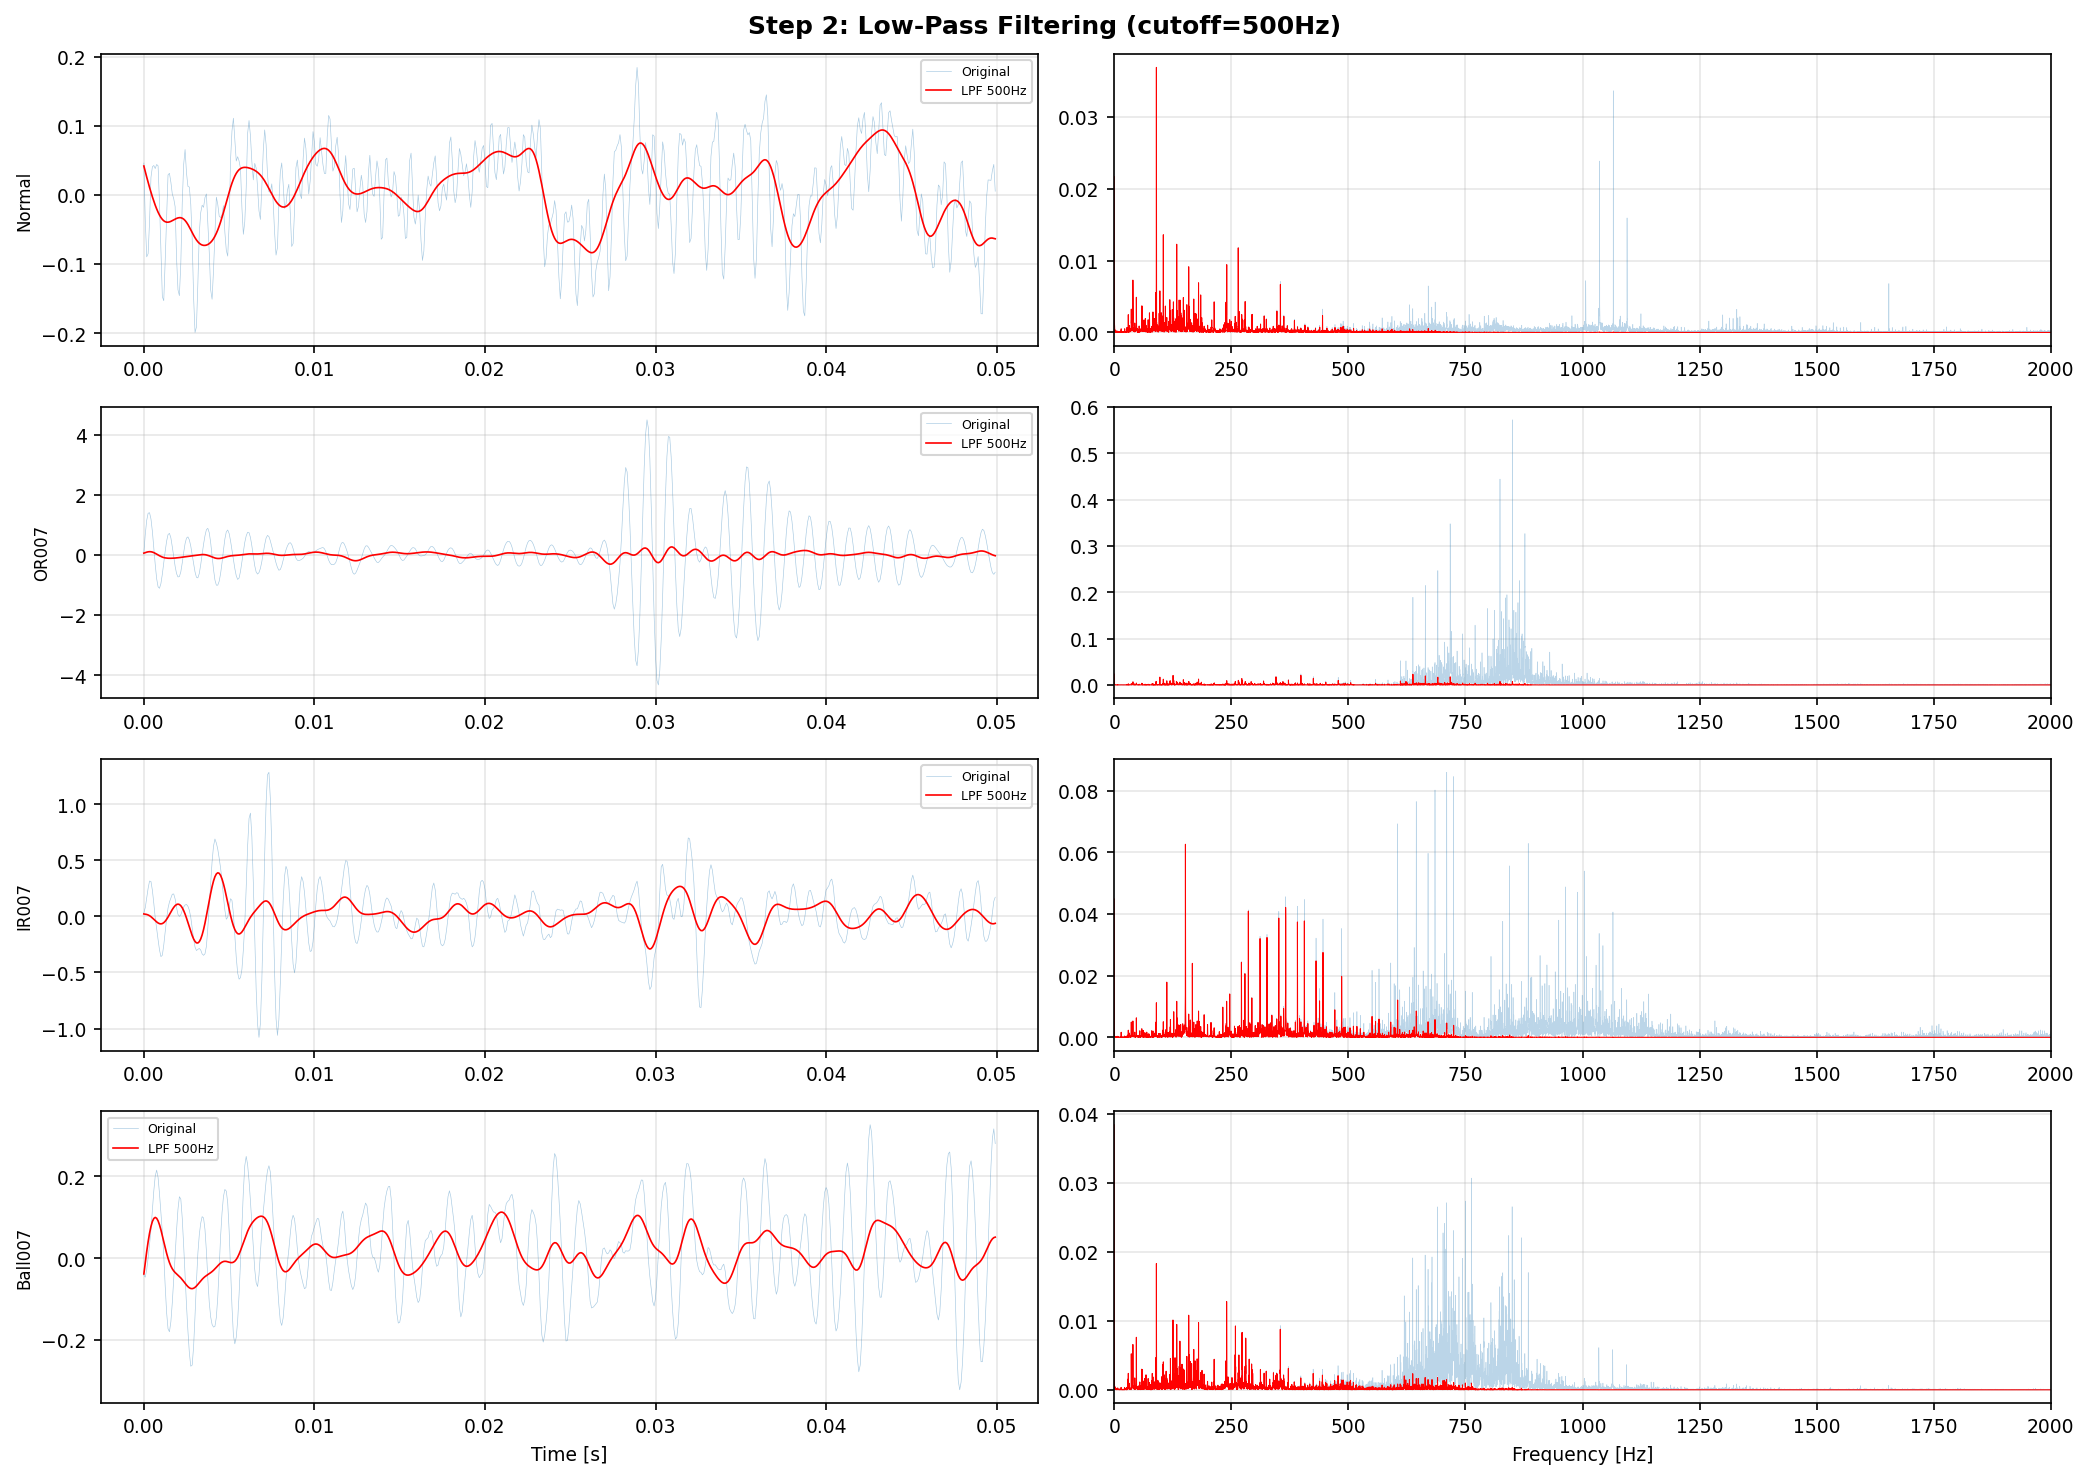

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
for i, label in enumerate(rep):
    x = data_dict[label]
    x_f = filtfilt(b_lpf, a_lpf, x)
    N = len(x)
    freq = fft.rfftfreq(N, 1/fs)
    t = np.arange(N)/fs
    n_show = int(0.05*fs)
    axes[i,0].plot(t[:n_show], x[:n_show], alpha=0.4, lw=0.3, label='Original')
    axes[i,0].plot(t[:n_show], x_f[:n_show], lw=0.8, color='red', label='LPF 500Hz')
    axes[i,0].set_ylabel(label, fontsize=8)
    axes[i,0].legend(fontsize=6)
    axes[i,0].grid(True, alpha=0.3)
    axes[i,1].plot(freq, np.abs(fft.rfft(x))/(N/2), alpha=0.3, lw=0.3)
    axes[i,1].plot(freq, np.abs(fft.rfft(x_f))/(N/2), lw=0.5, color='red')
    axes[i,1].set_xlim(0, 2000)
    axes[i,1].grid(True, alpha=0.3)
axes[-1,0].set_xlabel('Time [s]')
axes[-1,1].set_xlabel('Frequency [Hz]')
fig.suptitle('Step 2: Low-Pass Filtering (cutoff=500Hz)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step2_filtering.png'), bbox_inches='tight')
plt.show()
plt.close()

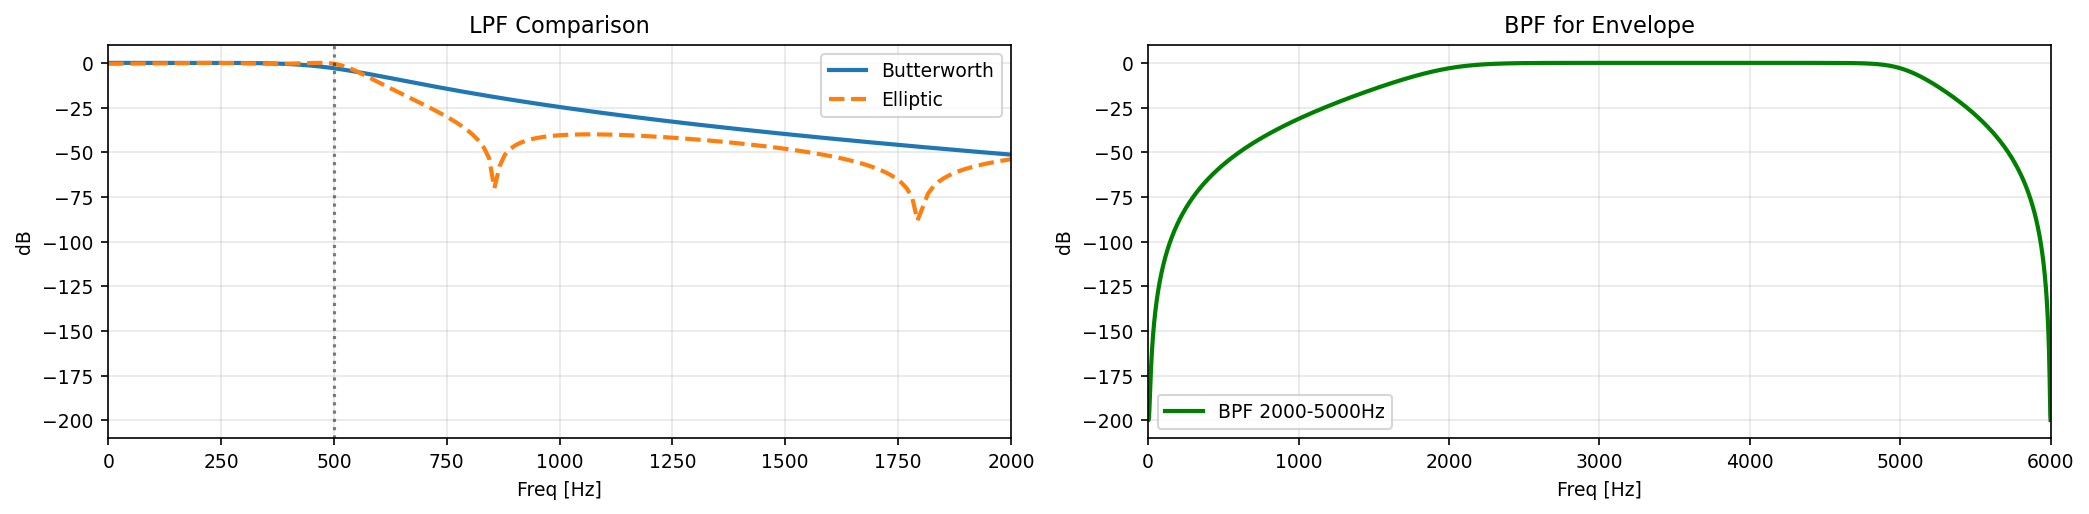

  saved step2 figures


54103

In [10]:
# Filter responses
b_butt, a_butt = butter(4, cutoff_lpf/(fs/2), btype='low')
b_ellip, a_ellip = signal.ellip(4, 0.5, 40, cutoff_lpf/(fs/2), btype='low')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
w1,h1 = signal.freqz(b_butt, a_butt, fs=fs)
w2,h2 = signal.freqz(b_ellip, a_ellip, fs=fs)
axes[0].plot(w1, 20*np.log10(np.abs(h1)+1e-10), lw=2, label='Butterworth')
axes[0].plot(w2, 20*np.log10(np.abs(h2)+1e-10), lw=2, ls='--', label='Elliptic')
axes[0].axvline(cutoff_lpf, color='k', ls=':', alpha=0.5)
axes[0].set_xlim(0,2000)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('Freq [Hz]')
axes[0].set_ylabel('dB')
axes[0].set_title('LPF Comparison')
w3,h3 = signal.freqz(b_bp, a_bp, worN=4096, fs=fs)
axes[1].plot(w3, 20*np.log10(np.abs(h3)+1e-10), lw=2, color='green', label=f'BPF {low_bp}-{high_bp}Hz')
axes[1].set_xlim(0,fs/2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('Freq [Hz]')
axes[1].set_ylabel('dB')
axes[1].set_title('BPF for Envelope')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step2_filter_resp.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step2 figures")
gc.collect()

In [11]:
# ============================================================
# STEP 3: ENVELOPE ANALYSIS
# ============================================================
print("\n>>> STEP 3: Envelope Analysis")


>>> STEP 3: Envelope Analysis


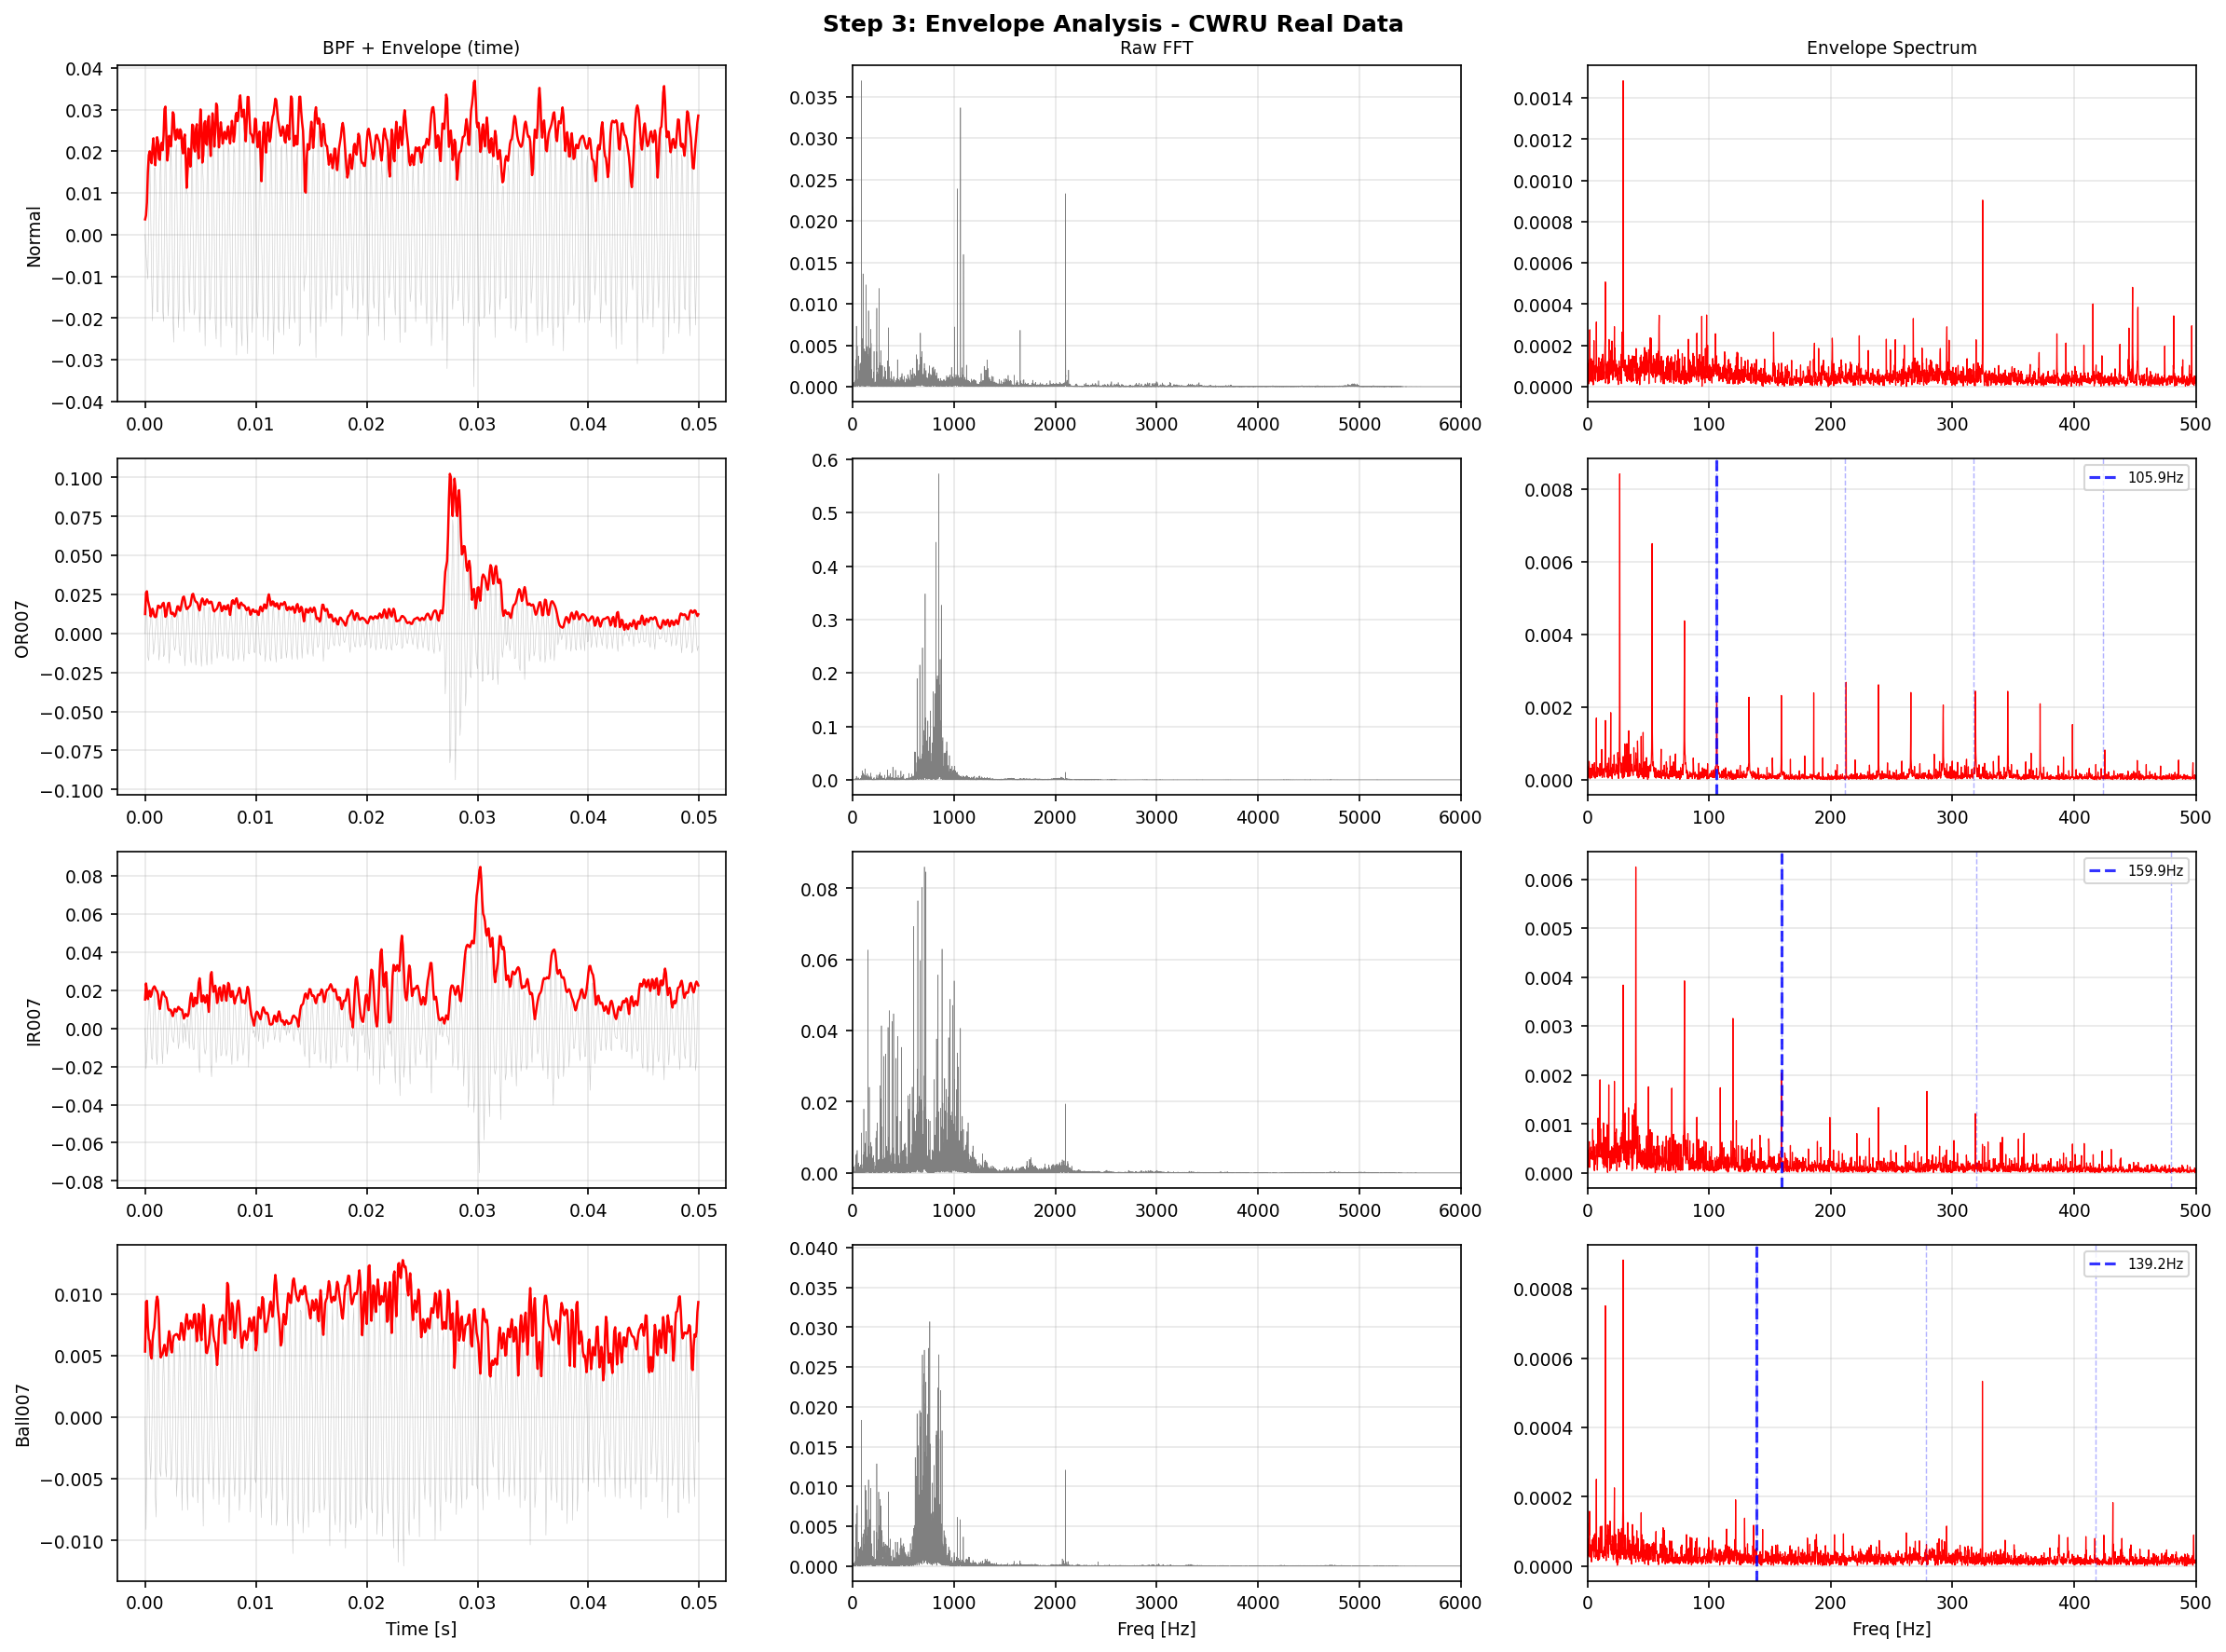

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
titles3 = ['BPF + Envelope (time)','Raw FFT','Envelope Spectrum']
for i, label in enumerate(rep):
    x = data_dict[label]
    N = len(x)
    freq = fft.rfftfreq(N, 1/fs)
    t = np.arange(N)/fs
    x_bp = filtfilt(b_bp, a_bp, x)
    env = np.abs(hilbert(x_bp))
    env_fft = np.abs(fft.rfft(env - np.mean(env)))/(N/2)
    raw_fft = np.abs(fft.rfft(x))/(N/2)
    
    n_show = int(0.05*fs)
    axes[i,0].plot(t[:n_show], x_bp[:n_show], alpha=0.4, lw=0.3, color='gray')
    axes[i,0].plot(t[:n_show], env[:n_show], lw=1.2, color='red')
    axes[i,0].set_ylabel(label, fontsize=9)
    if i==0: axes[i,0].set_title(titles3[0], fontsize=9)
    axes[i,0].grid(True, alpha=0.3)
    
    axes[i,1].plot(freq, raw_fft, lw=0.3, color='gray')
    axes[i,1].set_xlim(0, fs/2)
    if i==0: axes[i,1].set_title(titles3[1], fontsize=9)
    axes[i,1].grid(True, alpha=0.3)
    
    axes[i,2].plot(freq, env_fft, lw=0.6, color='red')
    axes[i,2].set_xlim(0, 500)
    if i==0: axes[i,2].set_title(titles3[2], fontsize=9)
    axes[i,2].grid(True, alpha=0.3)
    ff = fault_ff[label]
    if ff:
        for h in range(1,6): axes[i,2].axvline(ff*h, color='blue', alpha=0.3, ls='--', lw=0.7)
        axes[i,2].axvline(ff, color='blue', alpha=0.8, ls='--', lw=1.5, label=f'{ff:.1f}Hz')
        axes[i,2].legend(fontsize=7, loc='upper right')
    del x_bp, env, env_fft, raw_fft
    gc.collect()
for j in range(3): axes[-1,j].set_xlabel('Freq [Hz]' if j>0 else 'Time [s]')
fig.suptitle('Step 3: Envelope Analysis - CWRU Real Data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step3_envelope.png'), bbox_inches='tight')
plt.show()
plt.close()

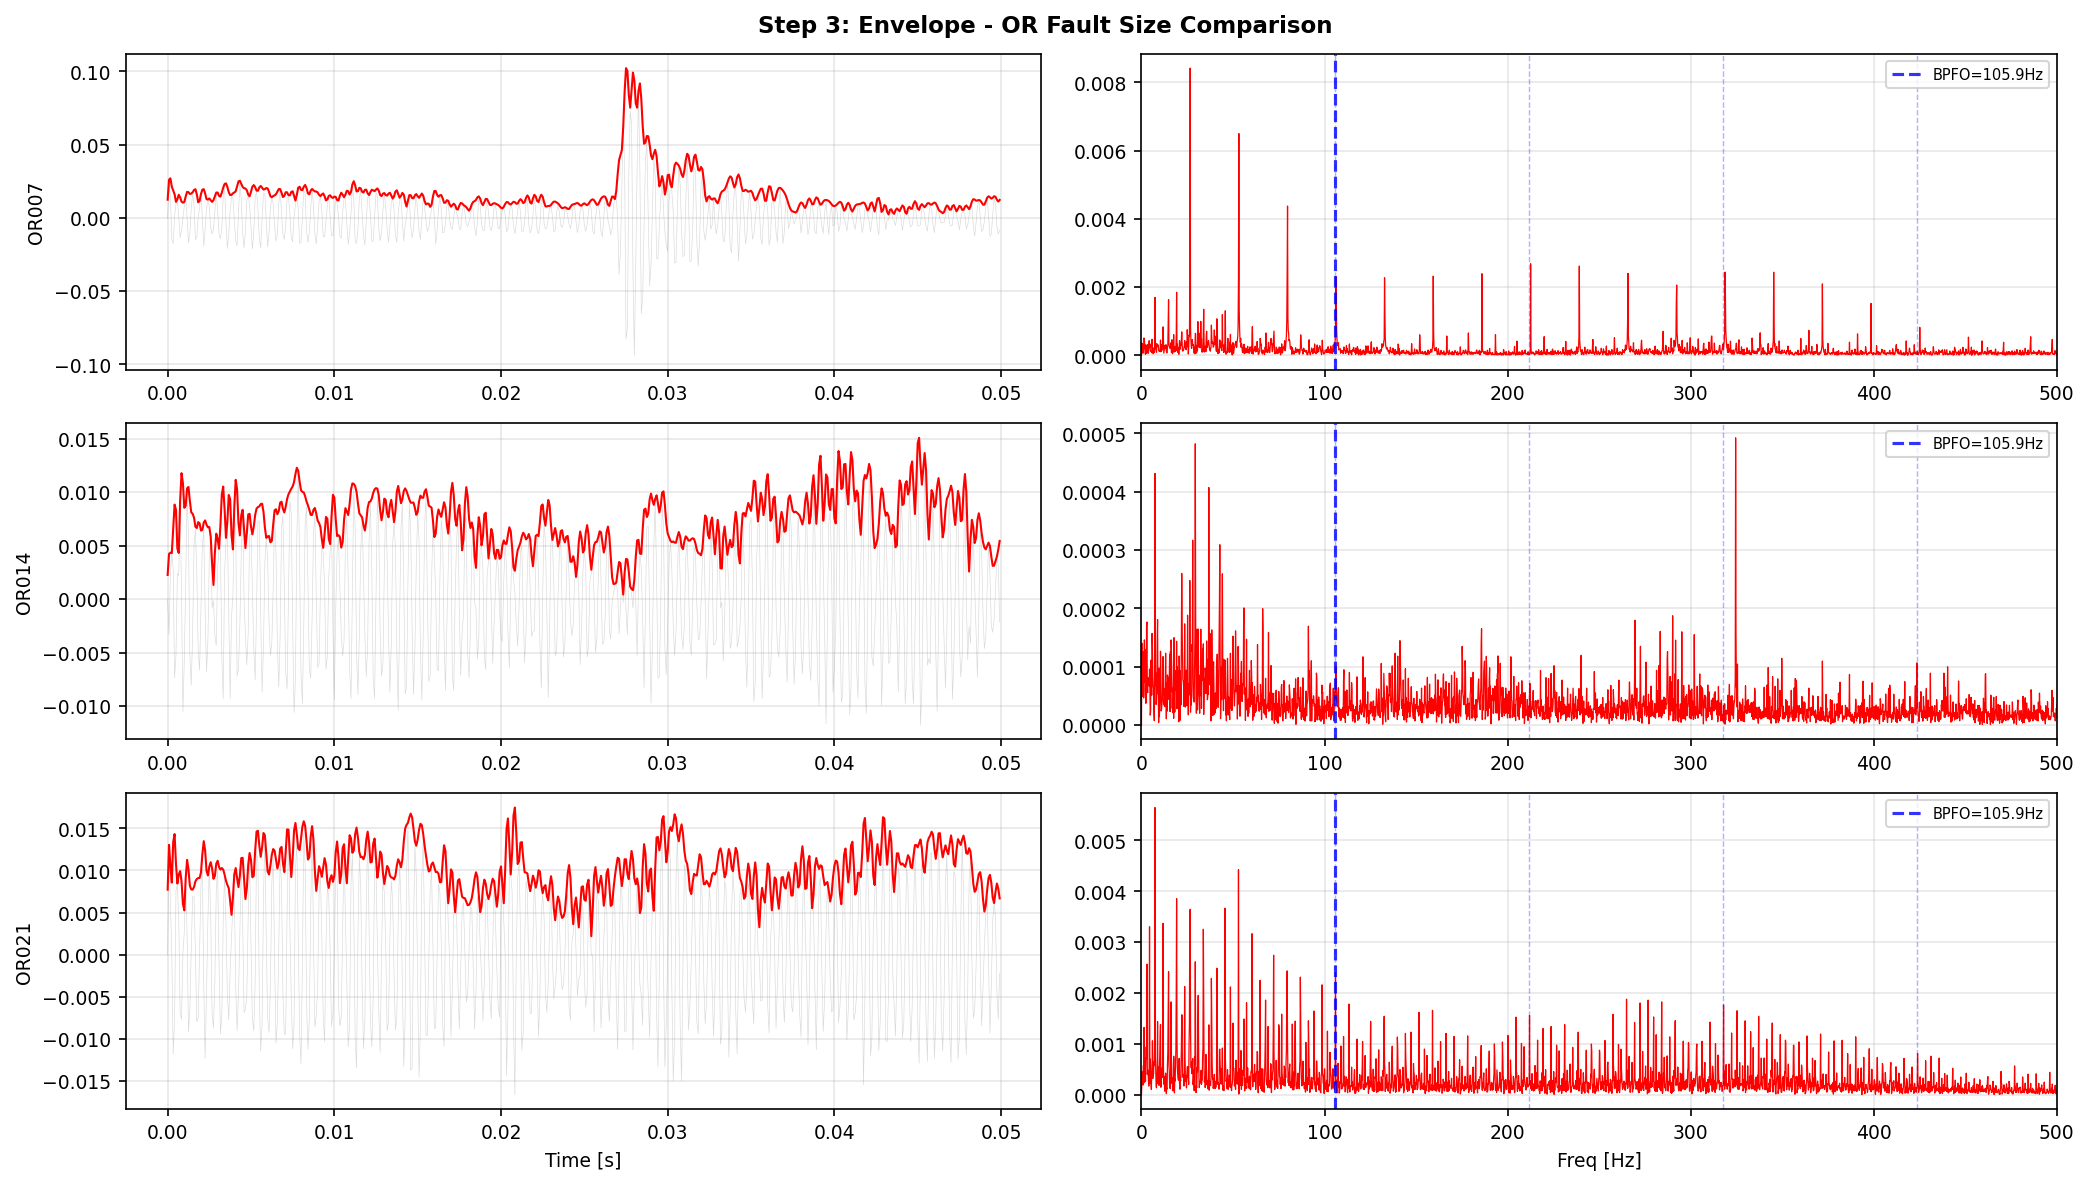

  saved step3 figures


24

In [13]:
# OR fault size comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for i, label in enumerate(['OR007','OR014','OR021']):
    x = data_dict[label]
    N=len(x)
    freq=fft.rfftfreq(N,1/fs)
    t=np.arange(N)/fs
    x_bp = filtfilt(b_bp, a_bp, x)
    env = np.abs(hilbert(x_bp))
    env_fft = np.abs(fft.rfft(env-np.mean(env)))/(N/2)
    n_show = int(0.05*fs)
    axes[i,0].plot(t[:n_show], x_bp[:n_show], alpha=0.3, lw=0.3, color='gray')
    axes[i,0].plot(t[:n_show], env[:n_show], lw=1, color='red')
    axes[i,0].set_ylabel(label)
    axes[i,0].grid(True, alpha=0.3)
    axes[i,1].plot(freq, env_fft, lw=0.6, color='red')
    axes[i,1].set_xlim(0, 500)
    for h in range(1,6): axes[i,1].axvline(BPFO*h, color='blue', alpha=0.3, ls='--', lw=0.7)
    axes[i,1].axvline(BPFO, color='blue', alpha=0.8, ls='--', label=f'BPFO={BPFO:.1f}Hz')
    axes[i,1].legend(fontsize=7)
    axes[i,1].grid(True, alpha=0.3)
    del x_bp, env, env_fft
    gc.collect()
axes[-1,0].set_xlabel('Time [s]')
axes[-1,1].set_xlabel('Freq [Hz]')
fig.suptitle('Step 3: Envelope - OR Fault Size Comparison', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step3_env_or.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step3 figures")
gc.collect()

In [14]:
# ============================================================
# STEP 4: STFT
# ============================================================
print("\n>>> STEP 4: STFT")
# Use shorter segment for memory
STFT_SAMPLES = 24000  # 2 seconds


>>> STEP 4: STFT


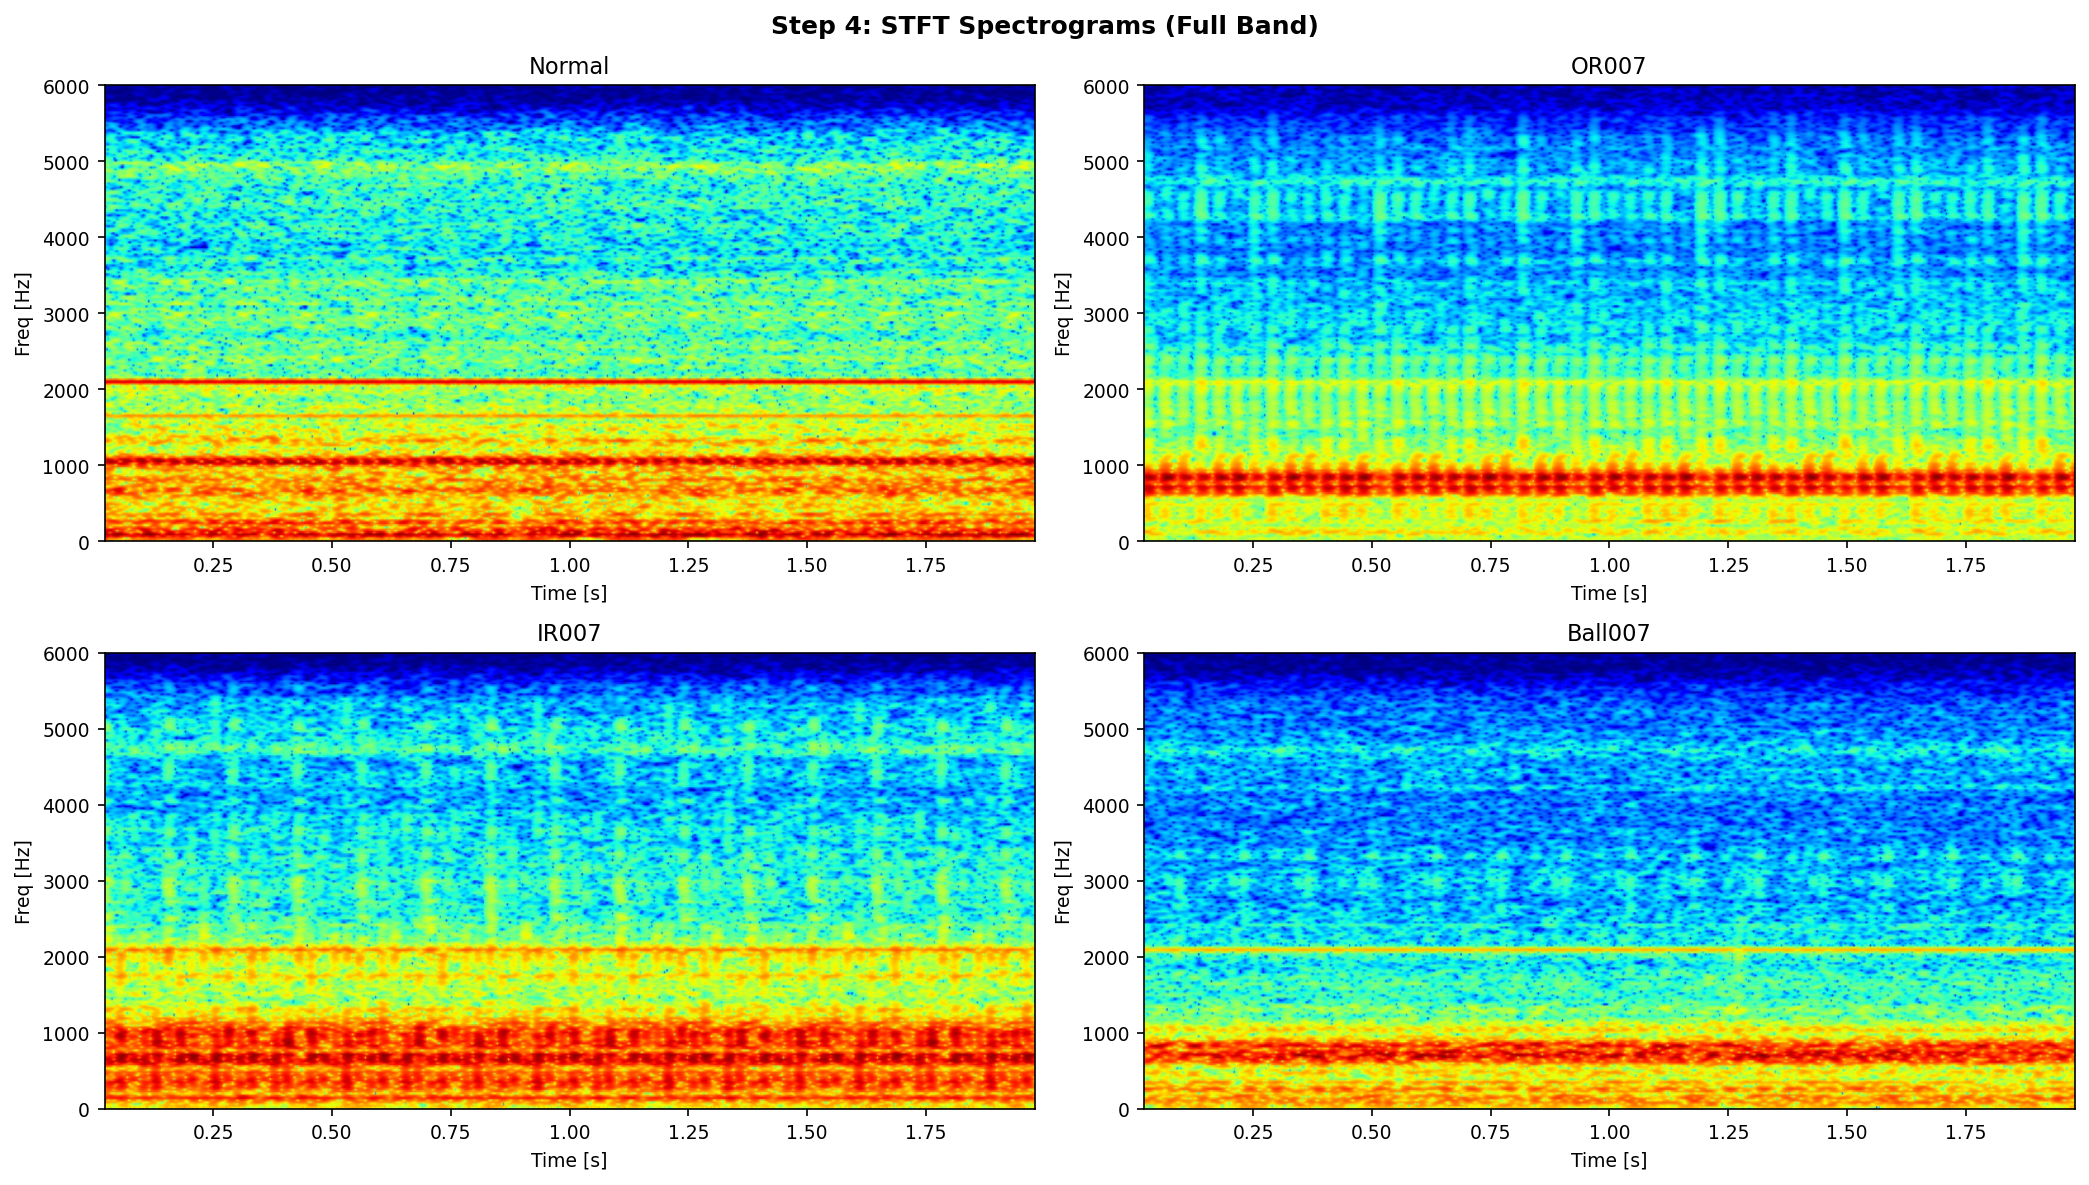

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, label in enumerate(rep):
    ax = axes[i//2, i%2]
    x = data_dict[label][:STFT_SAMPLES]
    f_s, t_s, Sxx = spectrogram(x, fs, nperseg=512, noverlap=480, window='hann')
    ax.pcolormesh(t_s, f_s, 10*np.log10(Sxx+1e-12), shading='gouraud', cmap='jet')
    ax.set_ylim(0, fs/2)
    ax.set_title(label)
    ax.set_ylabel('Freq [Hz]')
    ax.set_xlabel('Time [s]')
    del Sxx
    gc.collect()
fig.suptitle('Step 4: STFT Spectrograms (Full Band)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step4_stft.png'), bbox_inches='tight')
plt.show()
plt.close()

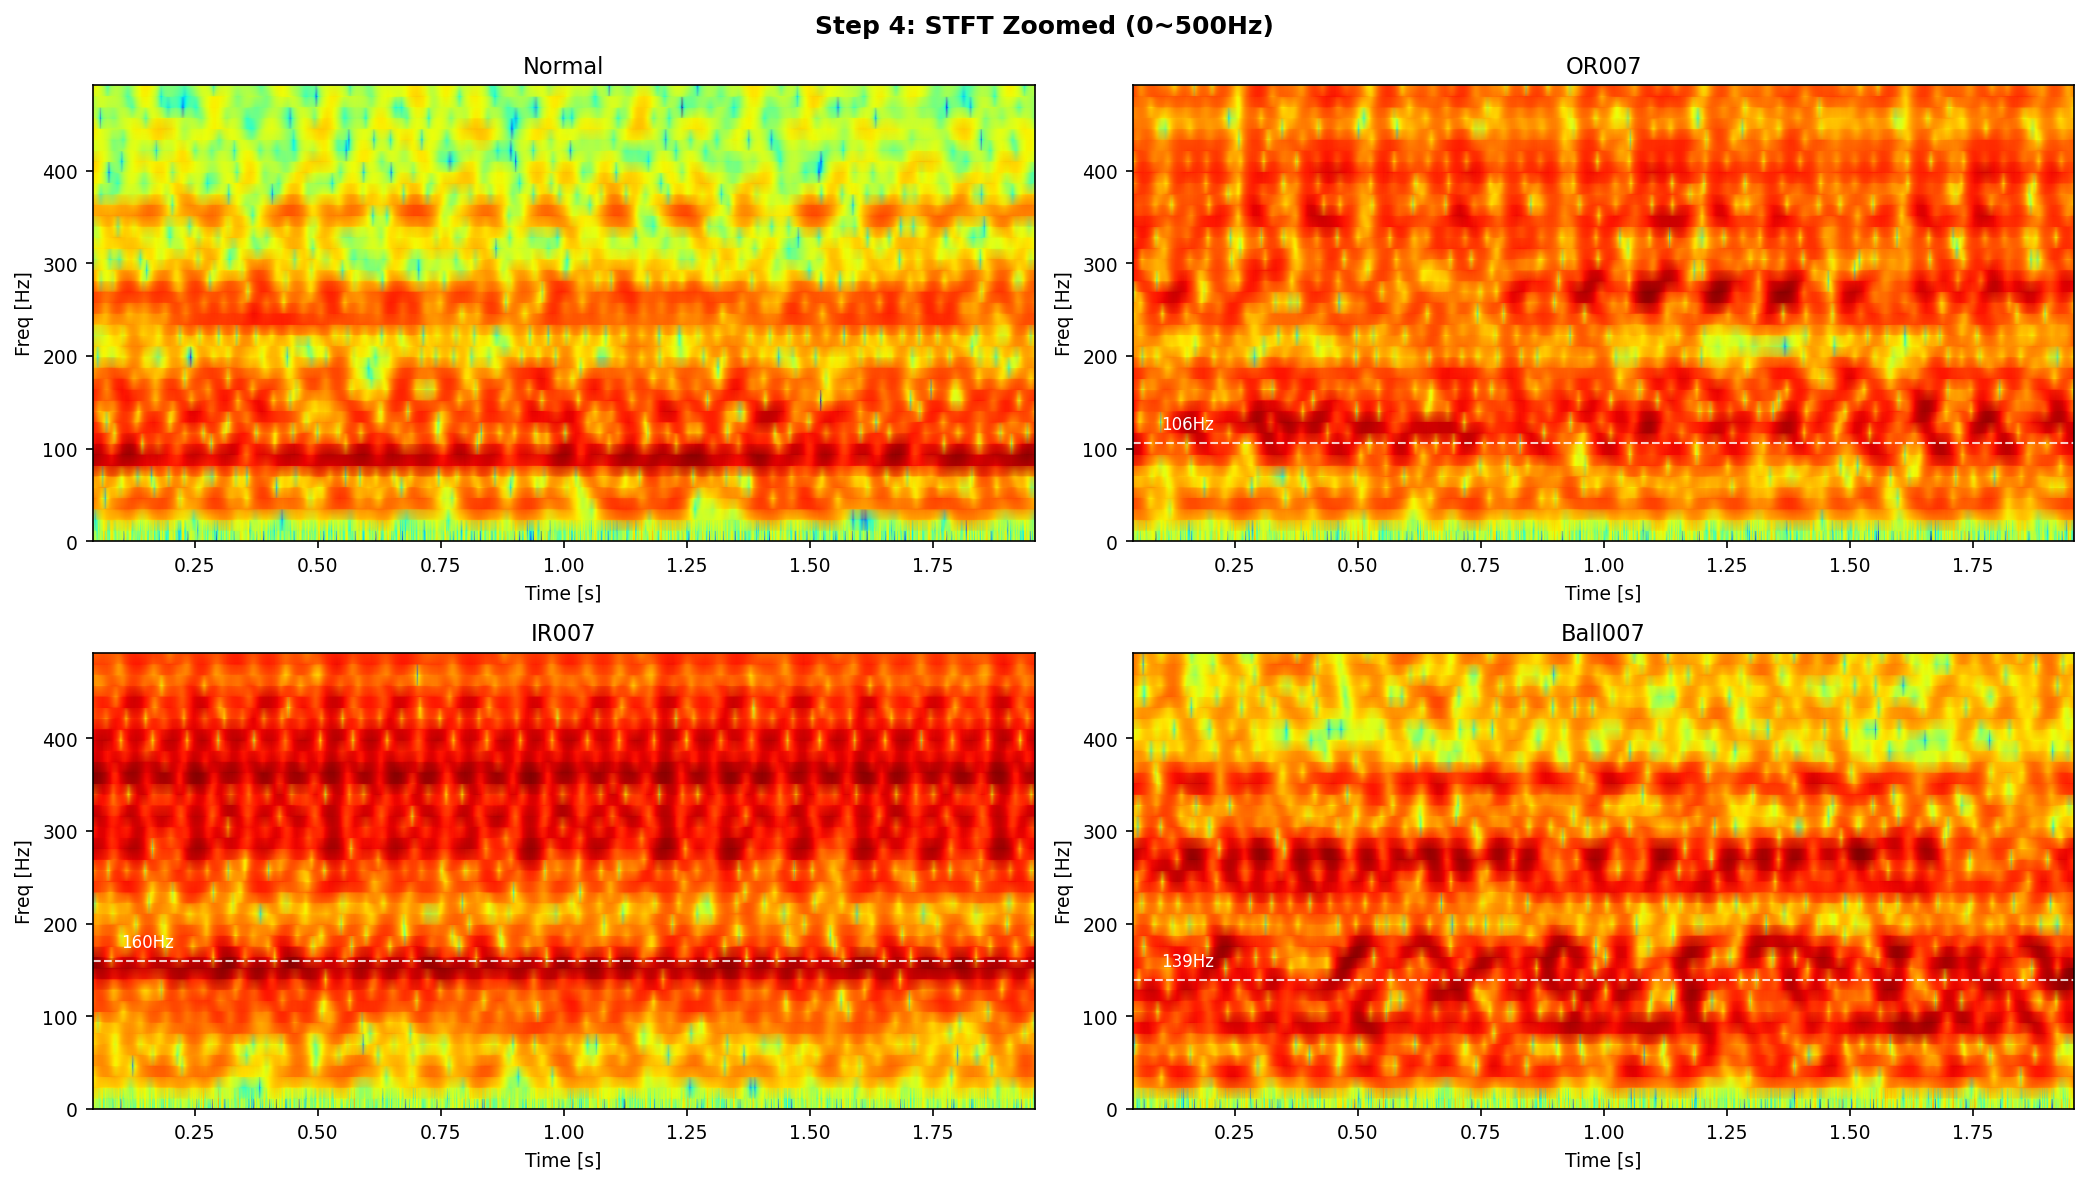

  saved step4 figures


0

In [16]:
# Zoomed low-freq
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, label in enumerate(rep):
    ax = axes[i//2, i%2]
    x = data_dict[label][:STFT_SAMPLES]
    x_lp = filtfilt(b_lpf, a_lpf, x)
    f_s, t_s, Sxx = spectrogram(x_lp, fs, nperseg=1024, noverlap=1000, window='hann')
    mask = f_s <= 500
    ax.pcolormesh(t_s, f_s[mask], 10*np.log10(Sxx[mask,:]+1e-12), shading='gouraud', cmap='jet')
    ax.set_title(label)
    ax.set_ylabel('Freq [Hz]')
    ax.set_xlabel('Time [s]')
    ff = fault_ff[label]
    if ff:
        ax.axhline(ff, color='white', ls='--', lw=1, alpha=0.8)
        ax.text(0.1, ff+15, f'{ff:.0f}Hz', color='white', fontsize=8)
    del x_lp, Sxx
    gc.collect()
fig.suptitle('Step 4: STFT Zoomed (0~500Hz)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step4_stft_zoom.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step4 figures")
gc.collect()

In [17]:
# ============================================================
# STEP 5: CLASSIFICATION
# ============================================================
print("\n>>> STEP 5: Classification")


>>> STEP 5: Classification


In [18]:
def extract_features(x, fs=12000):
    N = len(x)
    freq = fft.rfftfreq(N, 1/fs)
    X_mag = np.abs(fft.rfft(x))/(N/2)
    b_f, a_f = butter(4, [2000,5000], btype='band', fs=fs)
    try:
        x_bp = filtfilt(b_f, a_f, x)
        env = np.abs(hilbert(x_bp))
        env_fft = np.abs(fft.rfft(env-np.mean(env)))/(N/2)
    except:
        env_fft = np.zeros_like(X_mag)
    def be(s, f, lo, hi):
        m = (f>=lo)&(f<=hi)
        return np.sum(s[m]**2) if np.any(m) else 0.0
    rms = np.sqrt(np.mean(x**2))
    return [rms, np.mean((x-np.mean(x))**4)/(np.std(x)**4+1e-12),
            np.max(np.abs(x))/(rms+1e-12), np.max(x)-np.min(x),
            np.mean((x-np.mean(x))**3)/(np.std(x)**3+1e-12), np.std(x),
            be(X_mag,freq,0,200), be(X_mag,freq,200,500), be(X_mag,freq,2000,5000),
            be(env_fft,freq,BPFO-5,BPFO+5), be(env_fft,freq,BPFI-5,BPFI+5),
            be(env_fft,freq,2*BSF-5,2*BSF+5), be(env_fft,freq,0,200), be(env_fft,freq,200,500)]
 
feat_names = ['RMS','Kurtosis','Crest','P2P','Skewness','Std',
              'FFT_0_200','FFT_200_500','FFT_2k_5k',
              'Env_BPFO','Env_BPFI','Env_BSF','Env_0_200','Env_200_500']

seg_len = 4096
lmap = {'Normal':0,'IR007':1,'IR014':1,'IR021':1,'OR007':2,'OR014':2,'OR021':2,
        'Ball007':3,'Ball014':3,'Ball021':3}
lnames = ['Normal','Inner','Outer','Ball']

In [19]:
X_all, y_all = [], []
for dl, x in data_dict.items():
    cls = lmap[dl]
    for si in range(len(x)//seg_len):
        seg = x[si*seg_len:(si+1)*seg_len]
        X_all.append(extract_features(seg, fs))
        y_all.append(cls)
X_all = np.array(X_all)
y_all = np.array(y_all)
 
print(f"  Samples: {len(y_all)}")
for c in range(4): print(f"    {lnames[c]}: {np.sum(y_all==c)}")
 
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=42, stratify=y_all)
 
clf_dt = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
yp_dt = clf_dt.predict(X_te)
acc_dt = np.mean(yp_dt==y_te)
 
clf_rf = RandomForestClassifier(100, random_state=42).fit(X_tr, y_tr)
yp_rf = clf_rf.predict(X_te)
acc_rf = np.mean(yp_rf==y_te)
 
print(f"\n  Decision Tree: {acc_dt:.4f}")
print(f"  Random Forest: {acc_rf:.4f}")
print(classification_report(y_te, yp_rf, target_names=lnames))

  Samples: 140
    Normal: 14
    Inner: 42
    Outer: 42
    Ball: 42

  Decision Tree: 0.9048
  Random Forest: 0.9762
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         4
       Inner       1.00      0.92      0.96        12
       Outer       1.00      1.00      1.00        13
        Ball       0.93      1.00      0.96        13

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



In [20]:
# K-Fold
kf = KFold(5, shuffle=True, random_state=42)
faccs = []
for fold, (tri,tei) in enumerate(kf.split(X_all)):
    c = RandomForestClassifier(100, random_state=42).fit(X_all[tri], y_all[tri])
    a = np.mean(c.predict(X_all[tei])==y_all[tei])
    faccs.append(a)
    print(f"  Fold {fold+1}: {a:.4f}")
print(f"  Mean: {np.mean(faccs):.4f} ± {np.std(faccs):.4f}")

  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 0.9643
  Fold 4: 1.0000
  Fold 5: 0.9286
  Mean: 0.9786 ± 0.0286


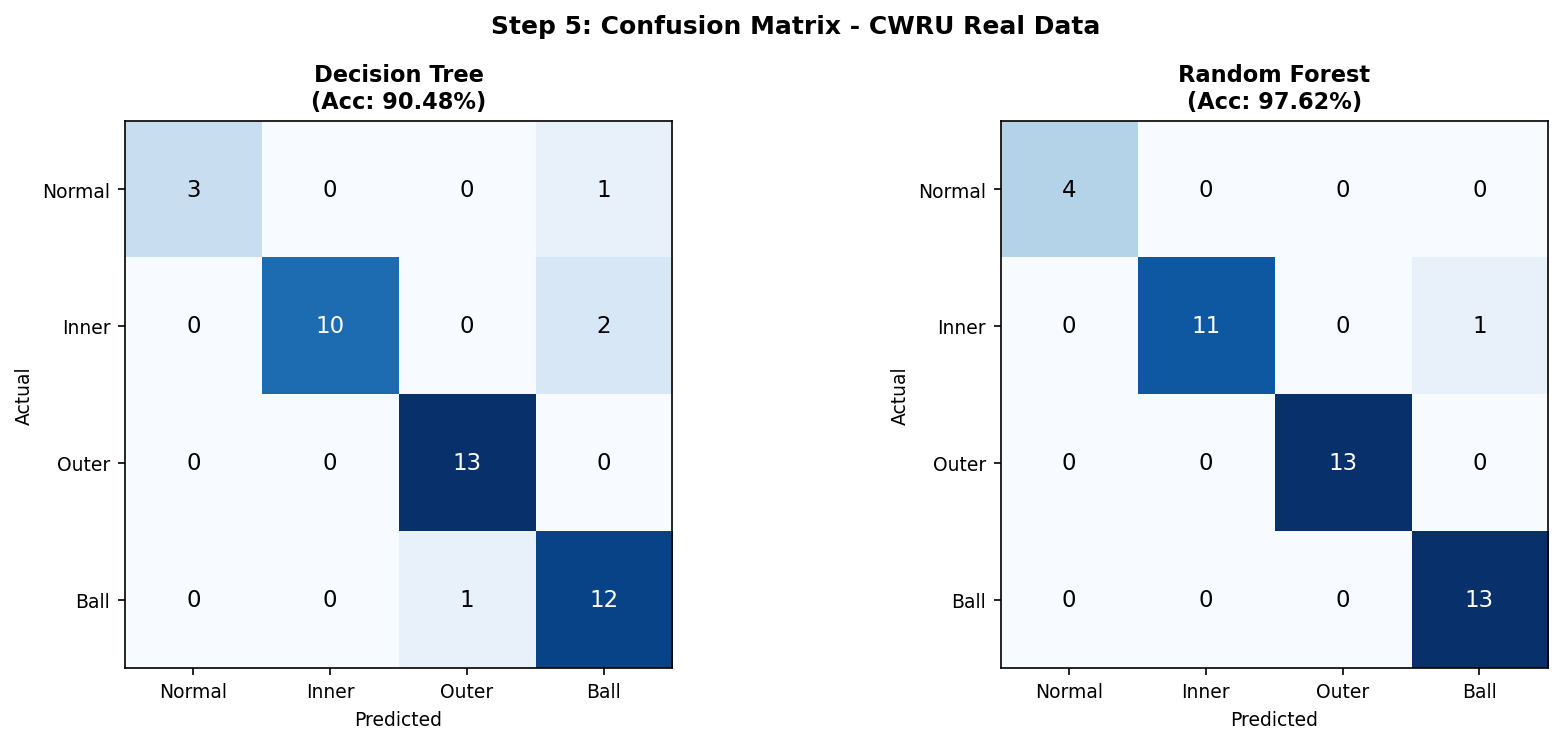

In [21]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, title in zip(axes, [yp_dt, yp_rf], ['Decision Tree','Random Forest']):
    cm = confusion_matrix(y_te, yp)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{title}\n(Acc: {np.mean(yp==y_te):.2%})', fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(lnames, fontsize=9)
    ax.set_yticklabels(lnames, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for r in range(4):
        for c in range(4):
            ax.text(c, r, cm[r,c], ha='center', va='center',
                    color='white' if cm[r,c]>cm.max()/2 else 'black', fontsize=11)
fig.suptitle('Step 5: Confusion Matrix - CWRU Real Data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step5_confusion.png'), bbox_inches='tight')
plt.show()
plt.close()

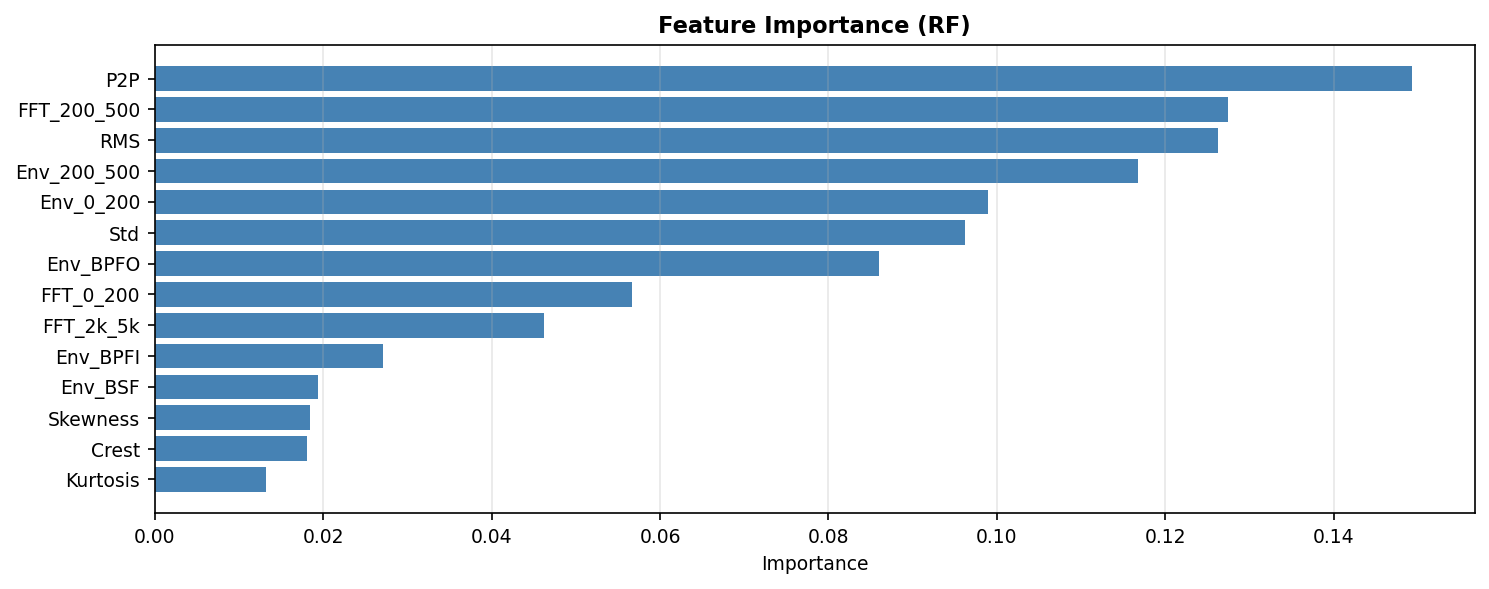

In [22]:
# Feature importance
imp = clf_rf.feature_importances_
si = np.argsort(imp)[::-1]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(imp)), imp[si[::-1]], color='steelblue')
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([feat_names[i] for i in si[::-1]], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (RF)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step5_importance.png'), bbox_inches='tight')
plt.show()
plt.close()

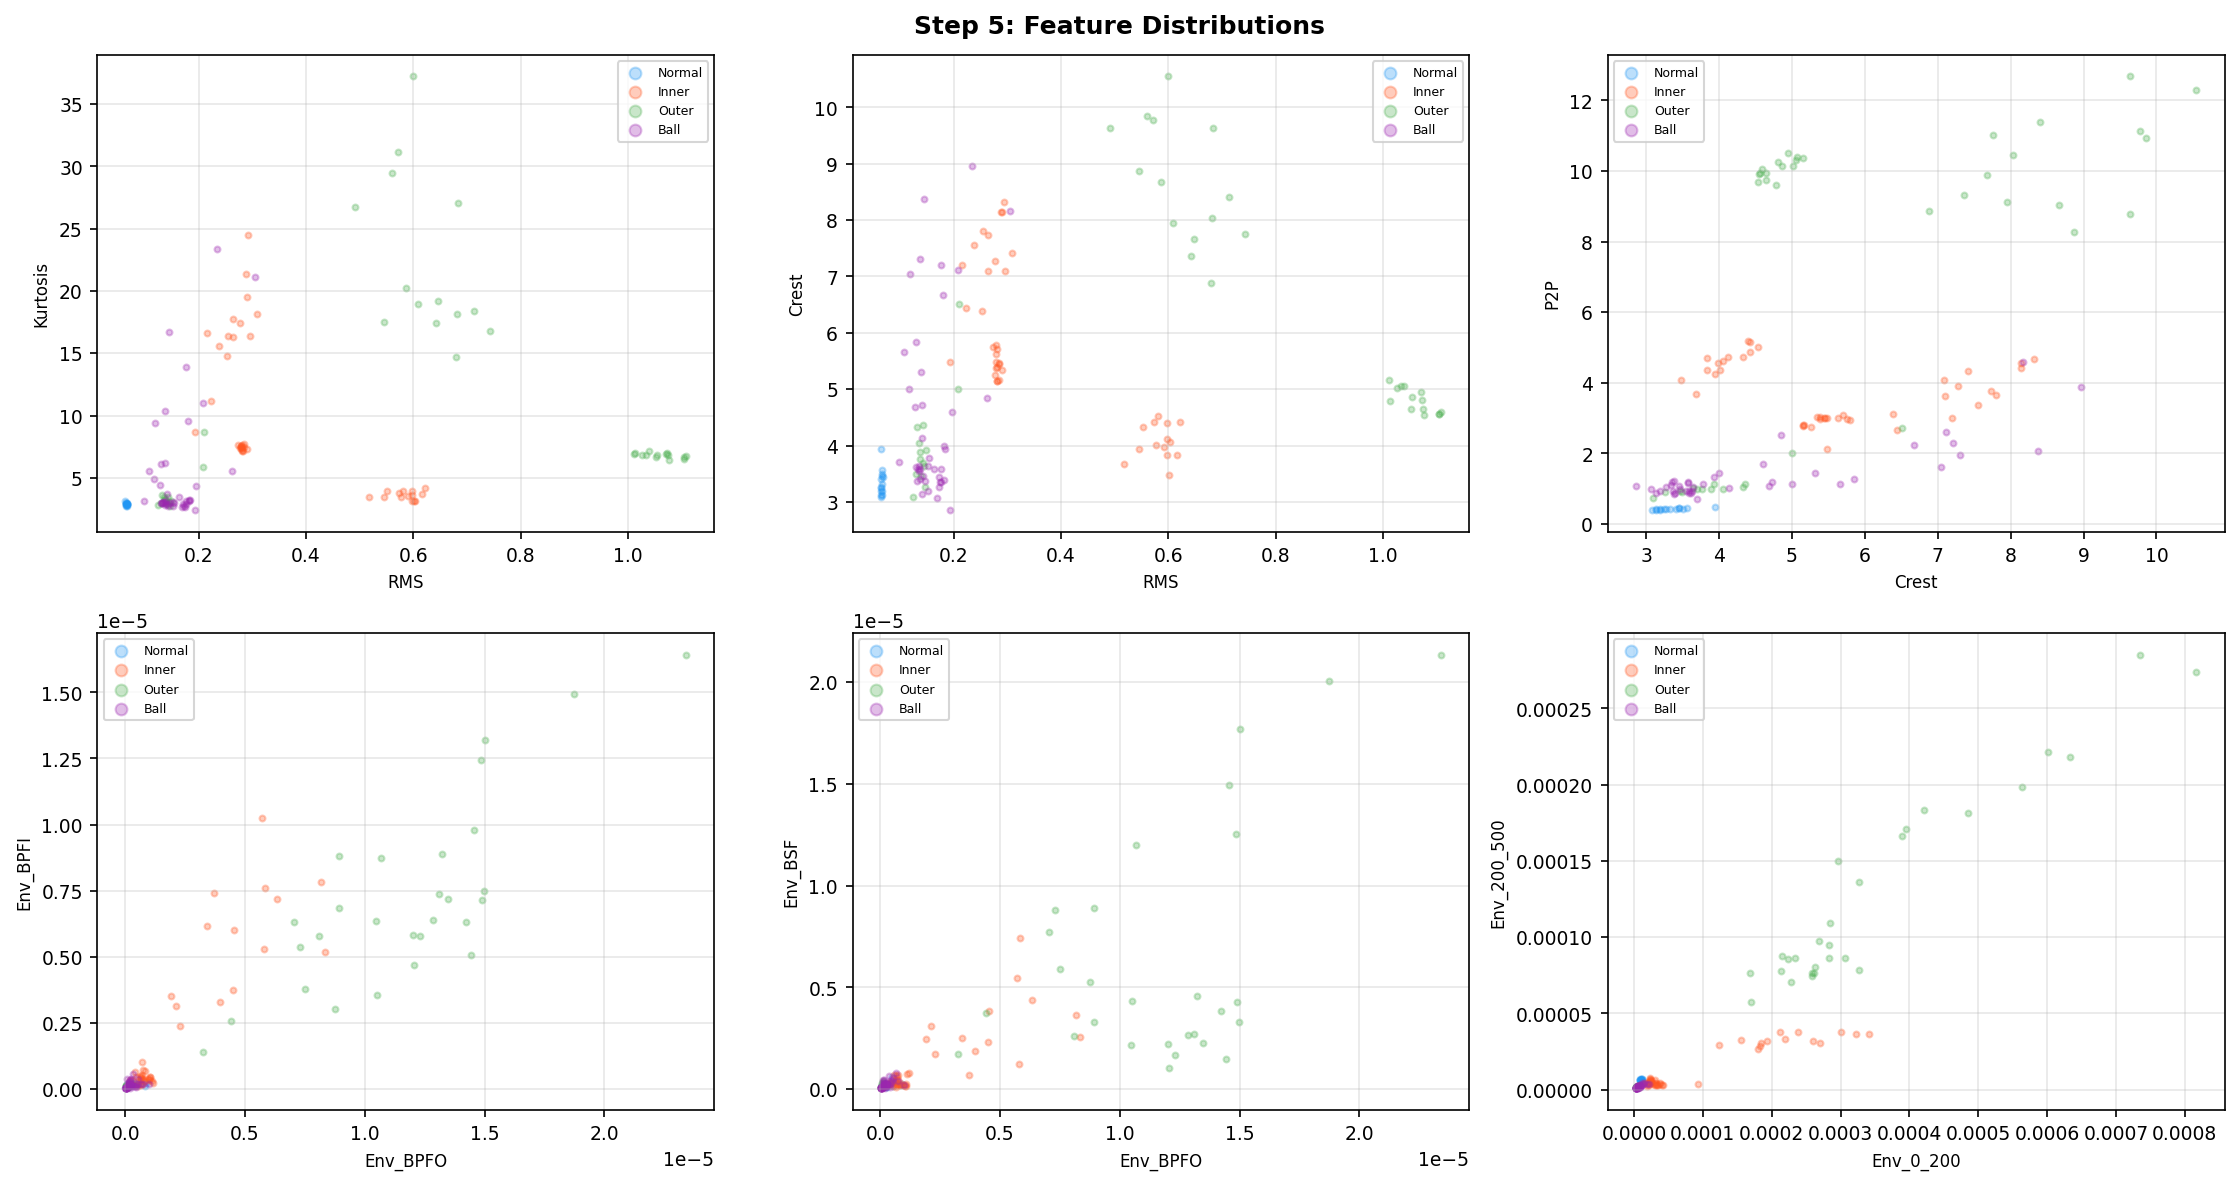

  saved step5 figures


16095

In [23]:
# Feature scatter
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
pairs = [(0,1),(0,2),(2,3),(9,10),(9,11),(12,13)]
cls_colors = ['#2196F3','#FF5722','#4CAF50','#9C27B0']
for ax, (fi,fj) in zip(axes.flat, pairs):
    for ci in range(4):
        m = y_all==ci
        ax.scatter(X_all[m,fi], X_all[m,fj], alpha=0.3, s=8, color=cls_colors[ci], label=lnames[ci])
    ax.set_xlabel(feat_names[fi], fontsize=8)
    ax.set_ylabel(feat_names[fj], fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, markerscale=2)
fig.suptitle('Step 5: Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'step5_features.png'), bbox_inches='tight')
plt.show()
plt.close()
print("  saved step5 figures")
gc.collect()

In [24]:
# ============================================================
# STEP 6: PROGNOSIS
# ============================================================
print("\n>>> STEP 6: Prognosis")


>>> STEP 6: Prognosis


In [25]:
# Build degradation trajectory from real data RMS
seg_prog = 12000
hi_vals, t_pts = [], []
progression = [('Normal',5),('OR007',4),('OR014',3),('OR021',3)]
cnt = 0
for dl, ns in progression:
    x = data_dict[dl]
    for si in range(ns):
        st = si*seg_prog
        if st+seg_prog > len(x): break
        hi_vals.append(np.sqrt(np.mean(x[st:st+seg_prog]**2)))
        t_pts.append(cnt*10)
        cnt+=1
hi_vals = np.array(hi_vals)
t_pts = np.array(t_pts)
 
n_obs = 10
t_ob = t_pts[:n_obs]
hi_ob = hi_vals[:n_obs]
threshold = hi_vals[-1] * 1.1

  RUL: 210.0 ± 0.0h, 95%CI: [210.0, 210.0]


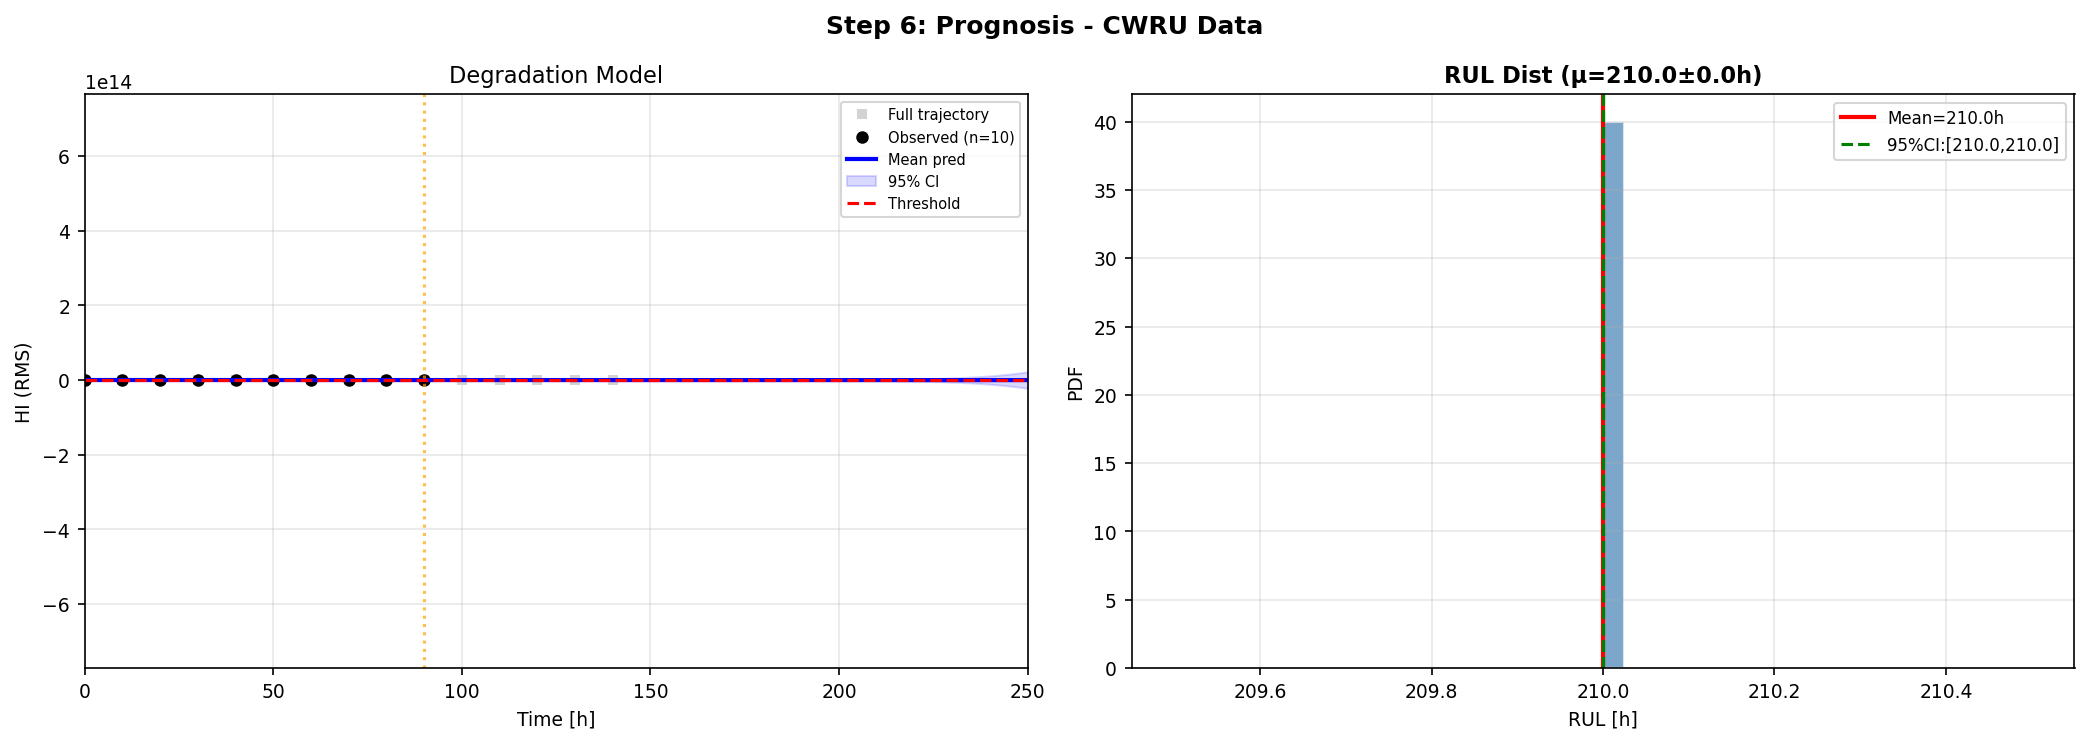

  saved step6_prognosis.png


In [26]:
def DegM(t_, a_, b_): 
    return a_*np.exp(b_*t_) + (hi_ob[0]-a_)
try:
    popt, pcov = curve_fit(DegM, t_ob, hi_ob, p0=[0.01,0.01], maxfev=10000)
    a_h, b_h = popt
    perr = np.sqrt(np.diag(pcov))
    t_pr = np.linspace(0, 300, 500)
    hi_pr = DegM(t_pr, a_h, b_h)
    cur_t = t_ob[-1]
    ft = np.interp(threshold, hi_pr, t_pr)
    RUL = max(0, ft - cur_t)
    
    # MC
    num_mc = 1000
    a_s = np.random.normal(a_h, perr[0], num_mc)
    b_s = np.random.normal(b_h, perr[1], num_mc)
    y_mc = np.array([DegM(t_pr, a, b) for a, b in zip(a_s, b_s)])
    m_mc = np.mean(y_mc, axis=0)
    s_mc = np.std(y_mc, axis=0)
    
    rul_s = []
    for a, b in zip(a_s, b_s):
        ys = DegM(t_pr, a, b)
        try:
            r = np.interp(threshold, ys, t_pr) - cur_t
            if 0<r<500: rul_s.append(r)
        except: pass
    rul_s = np.array(rul_s)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(t_pts, hi_vals, 's', color='lightgray', ms=4, label='Full trajectory')
    ax.plot(t_ob, hi_ob, 'ko', ms=5, label=f'Observed (n={n_obs})')
    ax.plot(t_pr, m_mc, 'b-', lw=2, label='Mean pred')
    ax.fill_between(t_pr, m_mc-2*s_mc, m_mc+2*s_mc, color='blue', alpha=0.15, label='95% CI')
    ax.axhline(threshold, color='r', ls='--', lw=1.5, label=f'Threshold')
    ax.axvline(cur_t, color='orange', ls=':', alpha=0.7)
    ax.set_xlabel('Time [h]')
    ax.set_ylabel('HI (RMS)')
    ax.set_title('Degradation Model')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 250)
    
    ax = axes[1]
    if len(rul_s)>10:
        ax.hist(rul_s, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
        mr = np.mean(rul_s)
        sr = np.std(rul_s)
        cl, ch = np.percentile(rul_s, [2.5, 97.5])
        ax.axvline(mr, color='red', lw=2, label=f'Mean={mr:.1f}h')
        ax.axvline(cl, color='green', ls='--', label=f'95%CI:[{cl:.1f},{ch:.1f}]')
        ax.axvline(ch, color='green', ls='--')
        ax.legend(fontsize=8)
        ax.set_title(f'RUL Dist (μ={mr:.1f}±{sr:.1f}h)', fontweight='bold')
        print(f"  RUL: {mr:.1f} ± {sr:.1f}h, 95%CI: [{cl:.1f}, {ch:.1f}]")
    ax.set_xlabel('RUL [h]')
    ax.set_ylabel('PDF')
    ax.grid(True, alpha=0.3)
    fig.suptitle('Step 6: Prognosis - CWRU Data', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'step6_prognosis.png'), bbox_inches='tight')
    plt.show()
    plt.close()
    print("  saved step6_prognosis.png")
except Exception as e:
    print(f"  Curve fit issue: {e}")

In [27]:
print("\n" + "="*55)
print("  ALL 6 STEPS COMPLETED SUCCESSFULLY!")
print("="*55)


  ALL 6 STEPS COMPLETED SUCCESSFULLY!
